# Create RMG Thermo Library from DFT Data

In [1]:
import input_generator as ig
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'Data', 'Cu111'))

In [3]:
def count_atoms(molecule_name):
    atom_counts = {'H': 0, 'C': 0, 'N': 0, 'O': 0, 'Cu': 0}

    # Replace 'X' with 'Cu' for counting purposes
    molecule_name = molecule_name.replace('X', 'Cu')

    # Regex to find elements and their counts
    pattern = re.compile(r'(Cu|H|C|N|O)(\d*)')

    # Find all matches
    matches = pattern.findall(molecule_name)

    for element, count in matches:
        count = int(count) if count else 1
        if element in atom_counts:
            atom_counts[element] += count

    return atom_counts

In [4]:
def create_composition_list(base_dir):
    compositions = {}

    # Iterate through all folders in the base directory
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)

        if os.path.isdir(folder_path):
            # Assume folder name is the molecule name
            molecule_name = folder_name

            # Count atoms in the molecule name
            atom_counts = count_atoms(molecule_name)

            # Store the composition
            compositions[molecule_name] = atom_counts

    return compositions

In [5]:
compositions = create_composition_list(base_dir)
print(compositions)

{'CH2OHX': {'H': 3, 'C': 1, 'N': 0, 'O': 1, 'Cu': 1}, 'CH2X': {'H': 2, 'C': 1, 'N': 0, 'O': 0, 'Cu': 1}, 'CH3X': {'H': 3, 'C': 1, 'N': 0, 'O': 0, 'Cu': 1}, 'CHOHX': {'H': 2, 'C': 1, 'N': 0, 'O': 1, 'Cu': 1}, 'CHOX': {'H': 1, 'C': 1, 'N': 0, 'O': 1, 'Cu': 1}, 'CHX': {'H': 1, 'C': 1, 'N': 0, 'O': 0, 'Cu': 1}, 'COCHOX': {'H': 1, 'C': 2, 'N': 0, 'O': 2, 'Cu': 1}, 'COHX': {'H': 1, 'C': 1, 'N': 0, 'O': 1, 'Cu': 1}, 'COOHX': {'H': 1, 'C': 1, 'N': 0, 'O': 2, 'Cu': 1}, 'COX': {'H': 0, 'C': 1, 'N': 0, 'O': 1, 'Cu': 1}, 'OCH2CH3X': {'H': 5, 'C': 2, 'N': 0, 'O': 1, 'Cu': 1}, 'OCHCH2OHX': {'H': 4, 'C': 2, 'N': 0, 'O': 2, 'Cu': 1}, 'OCHCH2X': {'H': 3, 'C': 2, 'N': 0, 'O': 1, 'Cu': 1}, 'OCHCH3X': {'H': 4, 'C': 2, 'N': 0, 'O': 1, 'Cu': 1}, 'OCHCHOHX': {'H': 3, 'C': 2, 'N': 0, 'O': 2, 'Cu': 1}, 'OCHCHX': {'H': 2, 'C': 2, 'N': 0, 'O': 1, 'Cu': 1}, 'OCHOCHX': {'H': 2, 'C': 2, 'N': 0, 'O': 2, 'Cu': 1}, 'OCHOX': {'H': 1, 'C': 1, 'N': 0, 'O': 2, 'Cu': 1}, 'XCOXCO': {'H': 0, 'C': 2, 'N': 0, 'O': 2, 'Cu': 2}}

In [6]:
def generate_traj_ps(base_dir):
    traj_ps = []

    # Iterate through all folders in the base directory
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)

        if os.path.isdir(folder_path):
            # Assume folder name is the molecule name
            molecule_name = folder_name

            # Define expected filenames
            files = [
                f'relax_restart_{molecule_name}.traj',
                f'zpe_log_{molecule_name}.txt',
                f'ads60_{molecule_name}.traj'
            ]

            # Generate absolute paths for the files
            abs_paths = [os.path.abspath(os.path.join(folder_path, file)) for file in files]

            # Check if all files exist
            missing_files = [file for file in files if not os.path.isfile(os.path.join(folder_path, file))]

            if missing_files:
                print(f"Error: Missing files in folder '{folder_name}': {', '.join(missing_files)}")
            else:
                # Append filenames to traj_ps if all files are present
                traj_ps.append(abs_paths)

    return traj_ps

In [7]:
traj_ps = generate_traj_ps(base_dir)
print(traj_ps)

[['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH2OHX/relax_restart_CH2OHX.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH2OHX/zpe_log_CH2OHX.txt', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH2OHX/ads60_CH2OHX.traj'], ['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH2X/relax_restart_CH2X.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH2X/zpe_log_CH2X.txt', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH2X/ads60_CH2X.traj'], ['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH3X/relax_restart_CH3X.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH3X/zpe_log_CH3X.txt', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CH3X/ads60_CH3X.traj'], ['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CHOHX/relax_restart_CHOHX.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu111/CHOHX/zpe

In [8]:
output_p = "recalc_dft_sp"

In [9]:
ig.input_generation(compositions, traj_ps, output_p, ocp=False)

-22.86630841
The heat of formation at 0 K for CH2OHX is -157.87468893094845 kJ/mol
The heat of formation at 0 K for CH2X is 77.21872540989385 kJ/mol
The heat of formation at 0 K for CH3X is -11.017378595923475 kJ/mol
The heat of formation at 0 K for CHOHX is -84.63792701856747 kJ/mol
The heat of formation at 0 K for CHOX is -105.04635029502693 kJ/mol
The heat of formation at 0 K for CHX is 135.26631979638643 kJ/mol
The heat of formation at 0 K for COCHOX is -273.0565360298573 kJ/mol
The heat of formation at 0 K for COHX is -78.25962817096011 kJ/mol
The heat of formation at 0 K for COOHX is -386.7745613997749 kJ/mol
The heat of formation at 0 K for COX is -182.42984225200223 kJ/mol
The heat of formation at 0 K for OCH2CH3X is -273.57096440420213 kJ/mol
The heat of formation at 0 K for OCHCH2OHX is -362.68229743726596 kJ/mol
The heat of formation at 0 K for OCHCH2X is -178.95812174395462 kJ/mol
The heat of formation at 0 K for OCHCH3X is -207.61216015050056 kJ/mol
The heat of formation a

In [10]:
def create_species_list(base_dir, output_file='sp_list.dat'):
    species_list = []

    # Iterate through all folders in the base directory
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)

        if os.path.isdir(folder_path):
            # Append the folder name with .dat to the list
            species_list.append(f"{folder_name}.dat")

    # Write the species list to a file
    with open(output_file, 'w') as file:
        for species in species_list:
            file.write(f"{species}\n")

    print(f"Species list has been written to {output_file}")

In [11]:
create_species_list(base_dir)

Species list has been written to sp_list.dat


successfully parsed file CH2OHX.dat
switching to 2D-gas for 2 lowest modes for CH2OHX
-167.43312909372636
-167.43312909372636


/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Scripts/Convert_Traj_RMG_Thermo/Cu111/input_generator.py:253: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  a_low = np.linalg.lstsq(Y, b)[0]
/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Scripts/Convert_Traj_RMG_Thermo/Cu111/input_generator.py:278: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  a_high = np.append(a_high, np.linalg.lstsq(Y, b)[0])
/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Scripts/Convert_Traj_RMG_Thermo/Cu111/input_generator.py:330: User

successfully parsed file CH2X.dat
73.81892288045991
73.81892288045991
successfully parsed file CH3X.dat
-18.07506231180544
-18.07506231180544
successfully parsed file CHOHX.dat
-89.37239614522655
-89.37239614522656
successfully parsed file CHOX.dat
-106.19224885149394
-106.19224885149394
successfully parsed file CHX.dat
132.97506789678906
132.97506789678906
successfully parsed file COCHOX.dat
switching to 2D-gas for 2 lowest modes for COCHOX
-276.8853044378237
-276.8853044378237
successfully parsed file COHX.dat
-79.83864115490681
-79.83864115490681
successfully parsed file COOHX.dat
switching to 2D-gas for 2 lowest modes for COOHX
-391.8786746579359
-391.8786746579359
successfully parsed file COX.dat
-180.43031516044573
-180.43031516044573
successfully parsed file OCH2CH3X.dat
switching to 2D-gas for 2 lowest modes for OCH2CH3X
-290.27838017288417
-290.27838017288417
successfully parsed file OCHCH2OHX.dat
switching to 2D-gas for 2 lowest modes for OCHCH2OHX
-374.38716641857735
-374.38

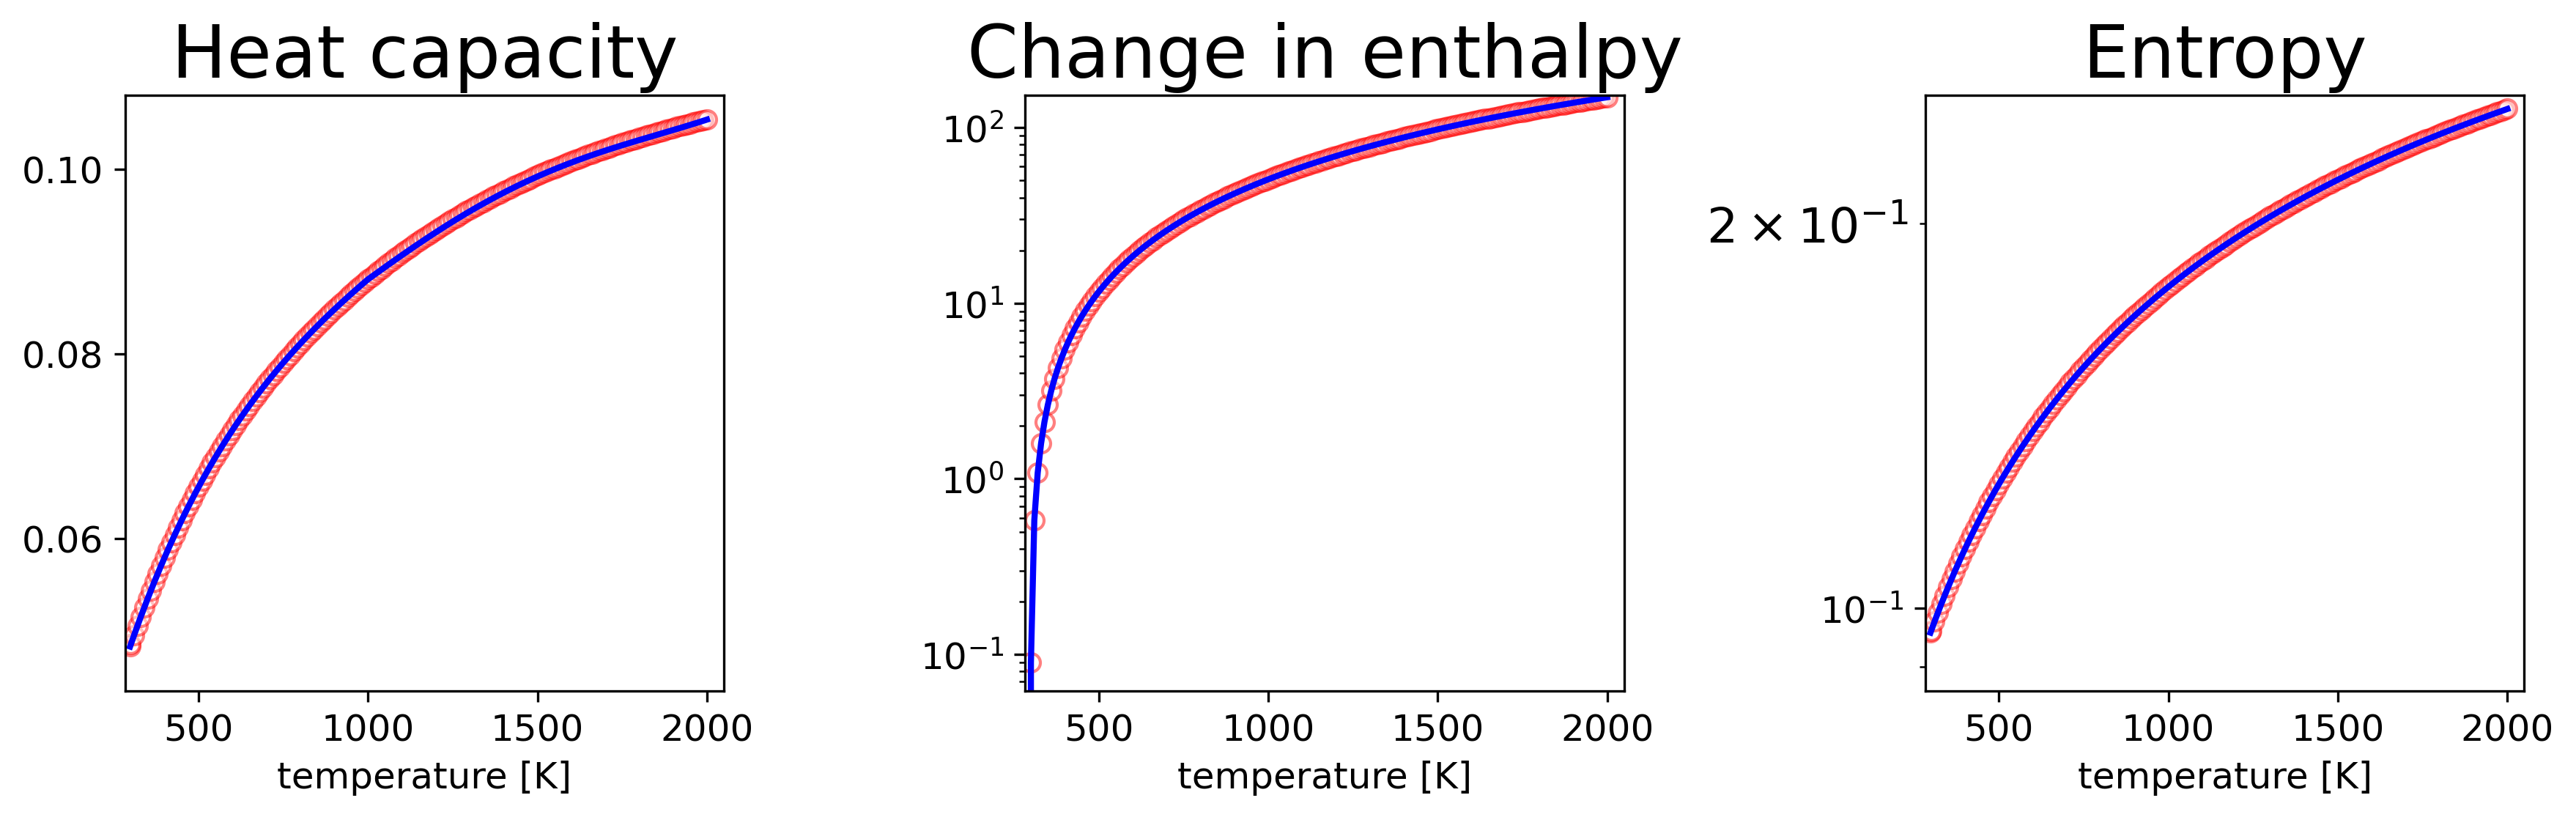

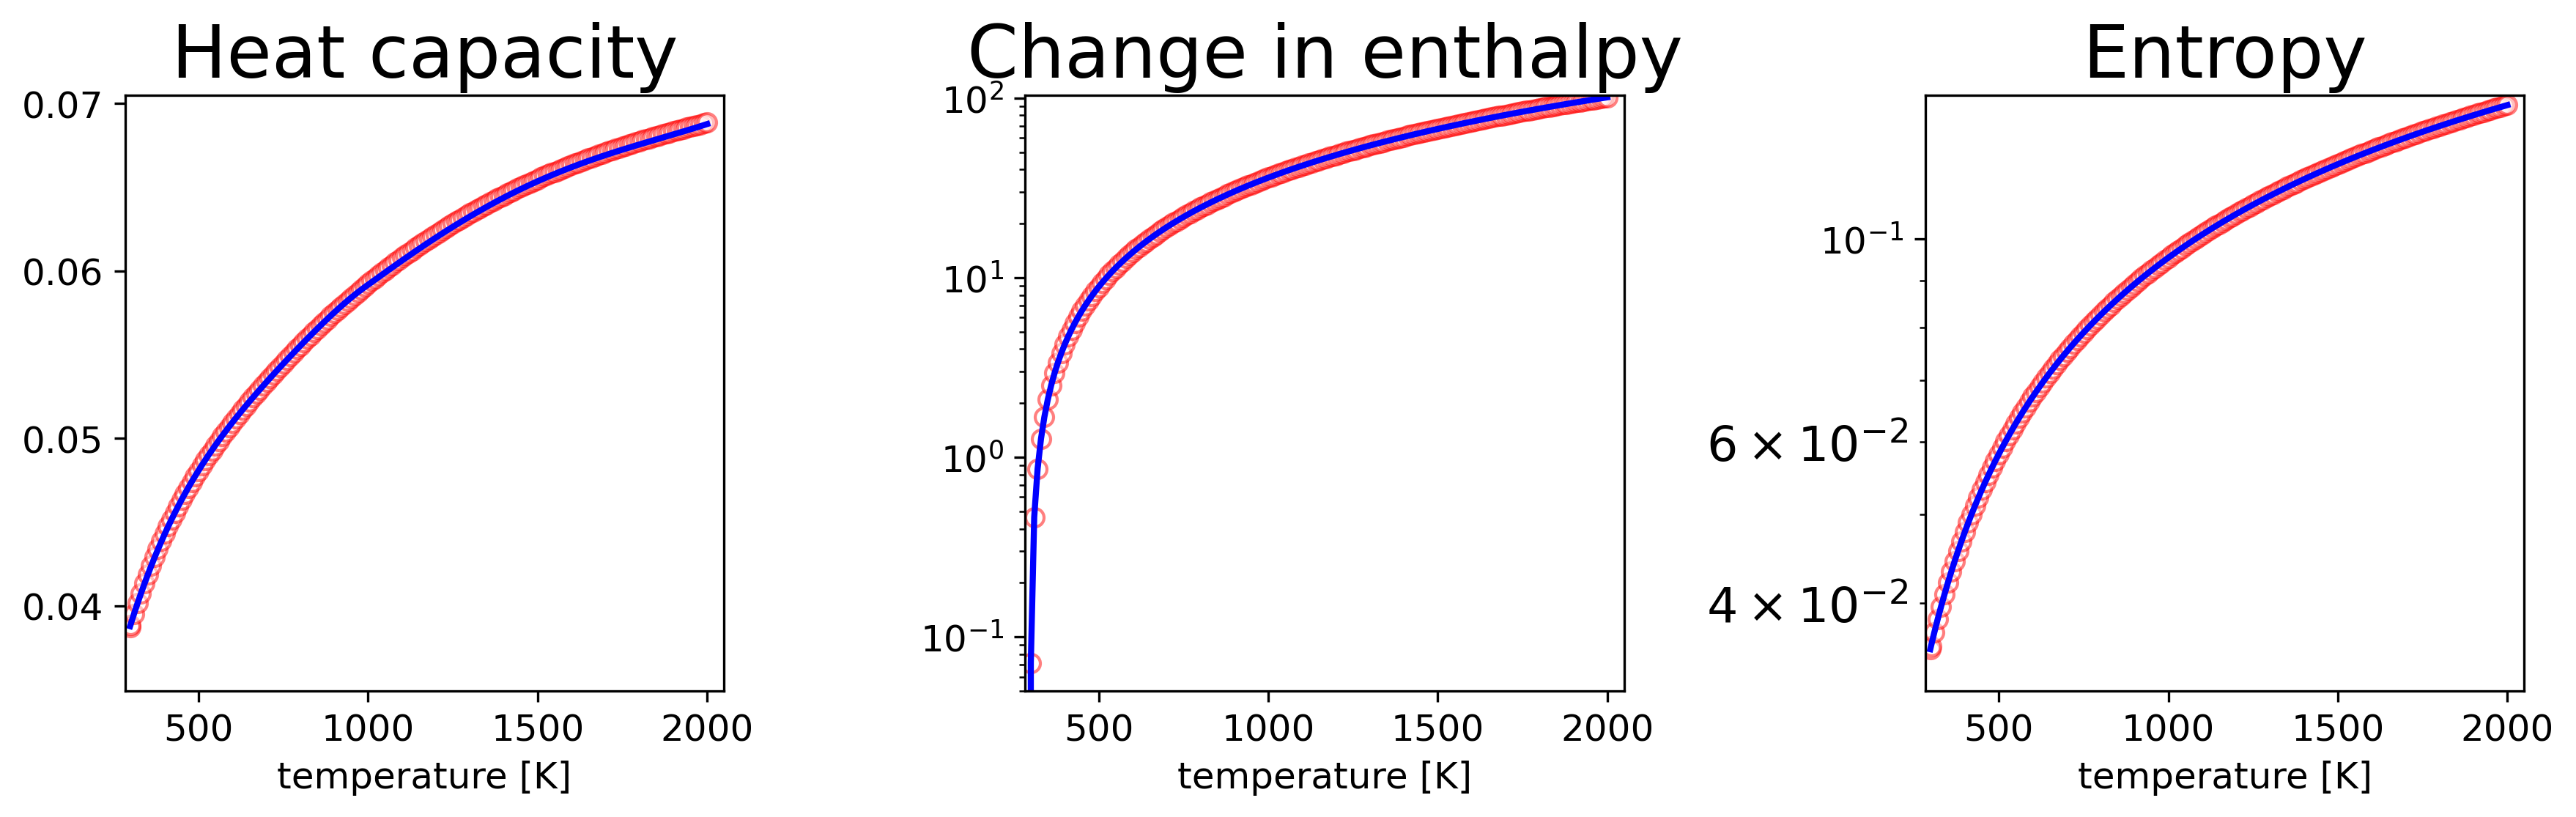

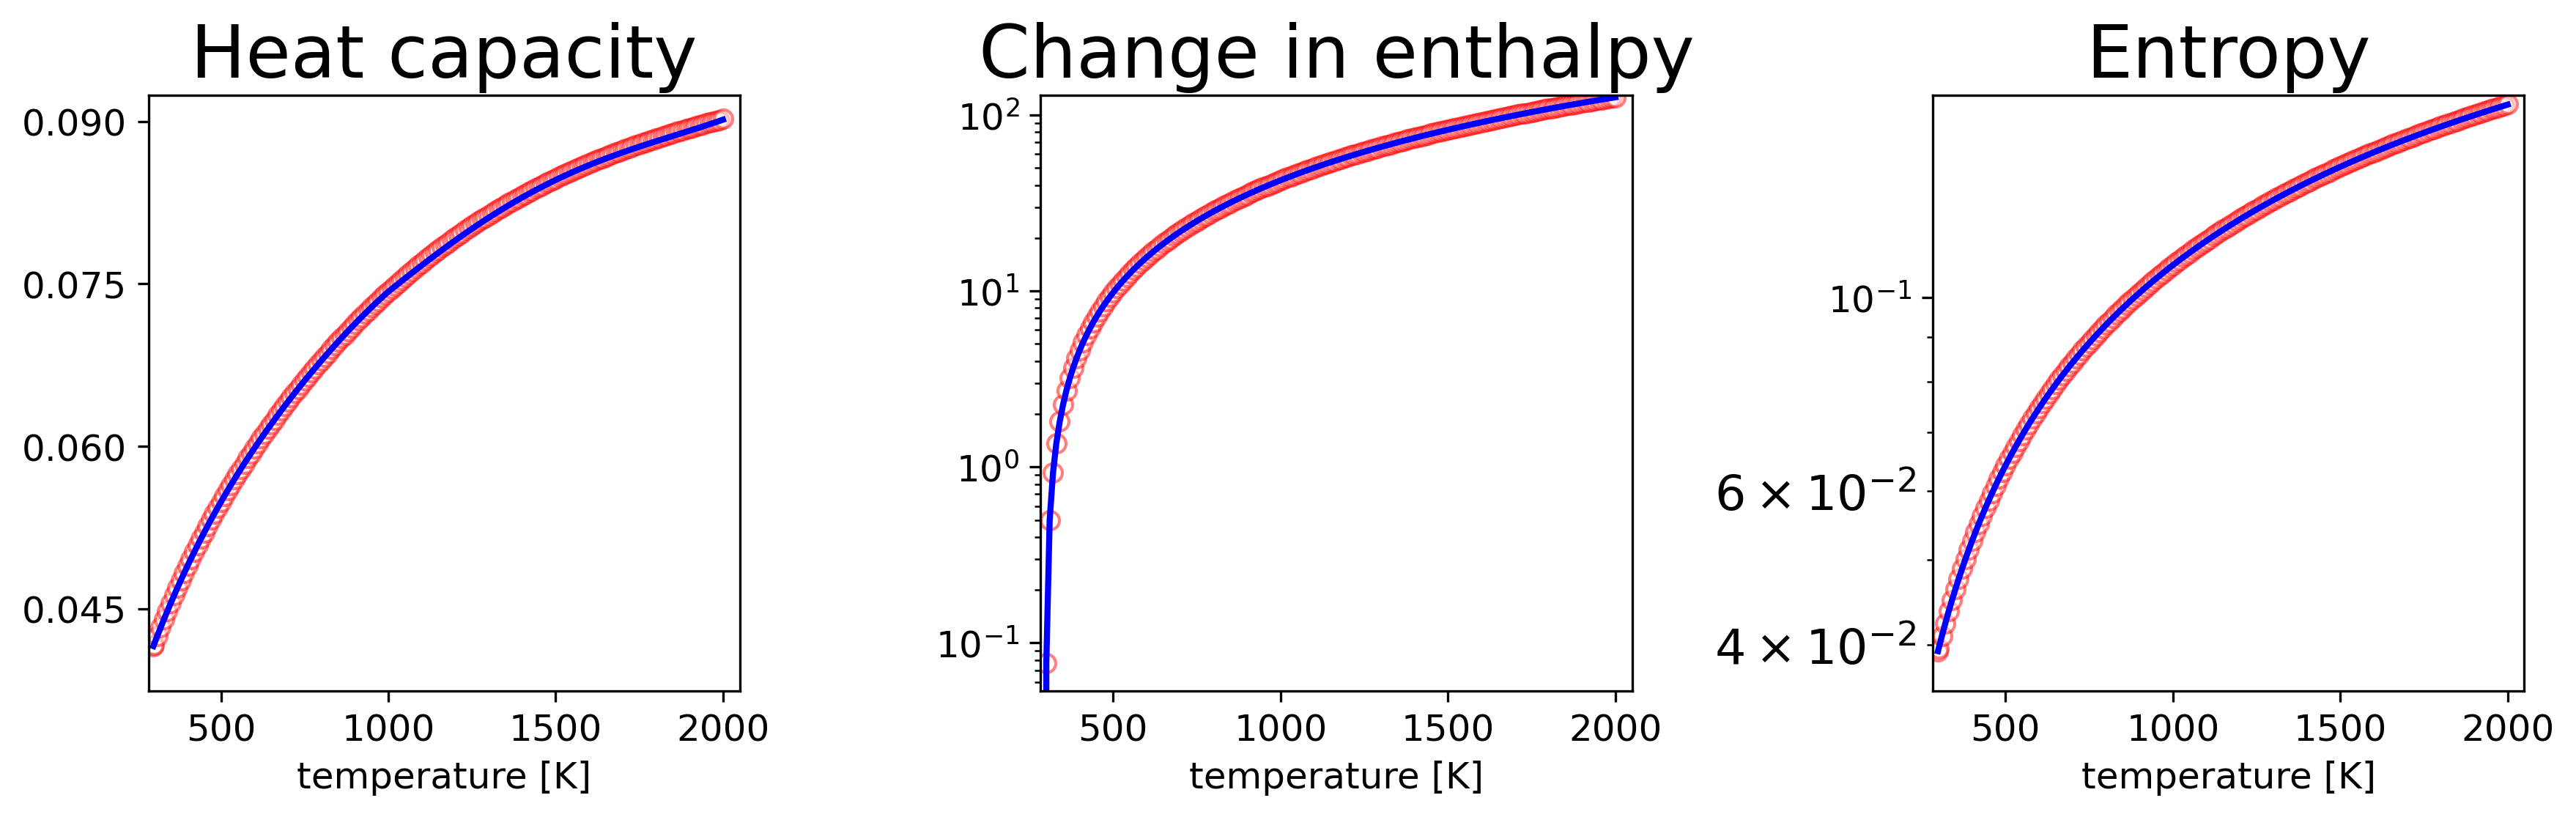

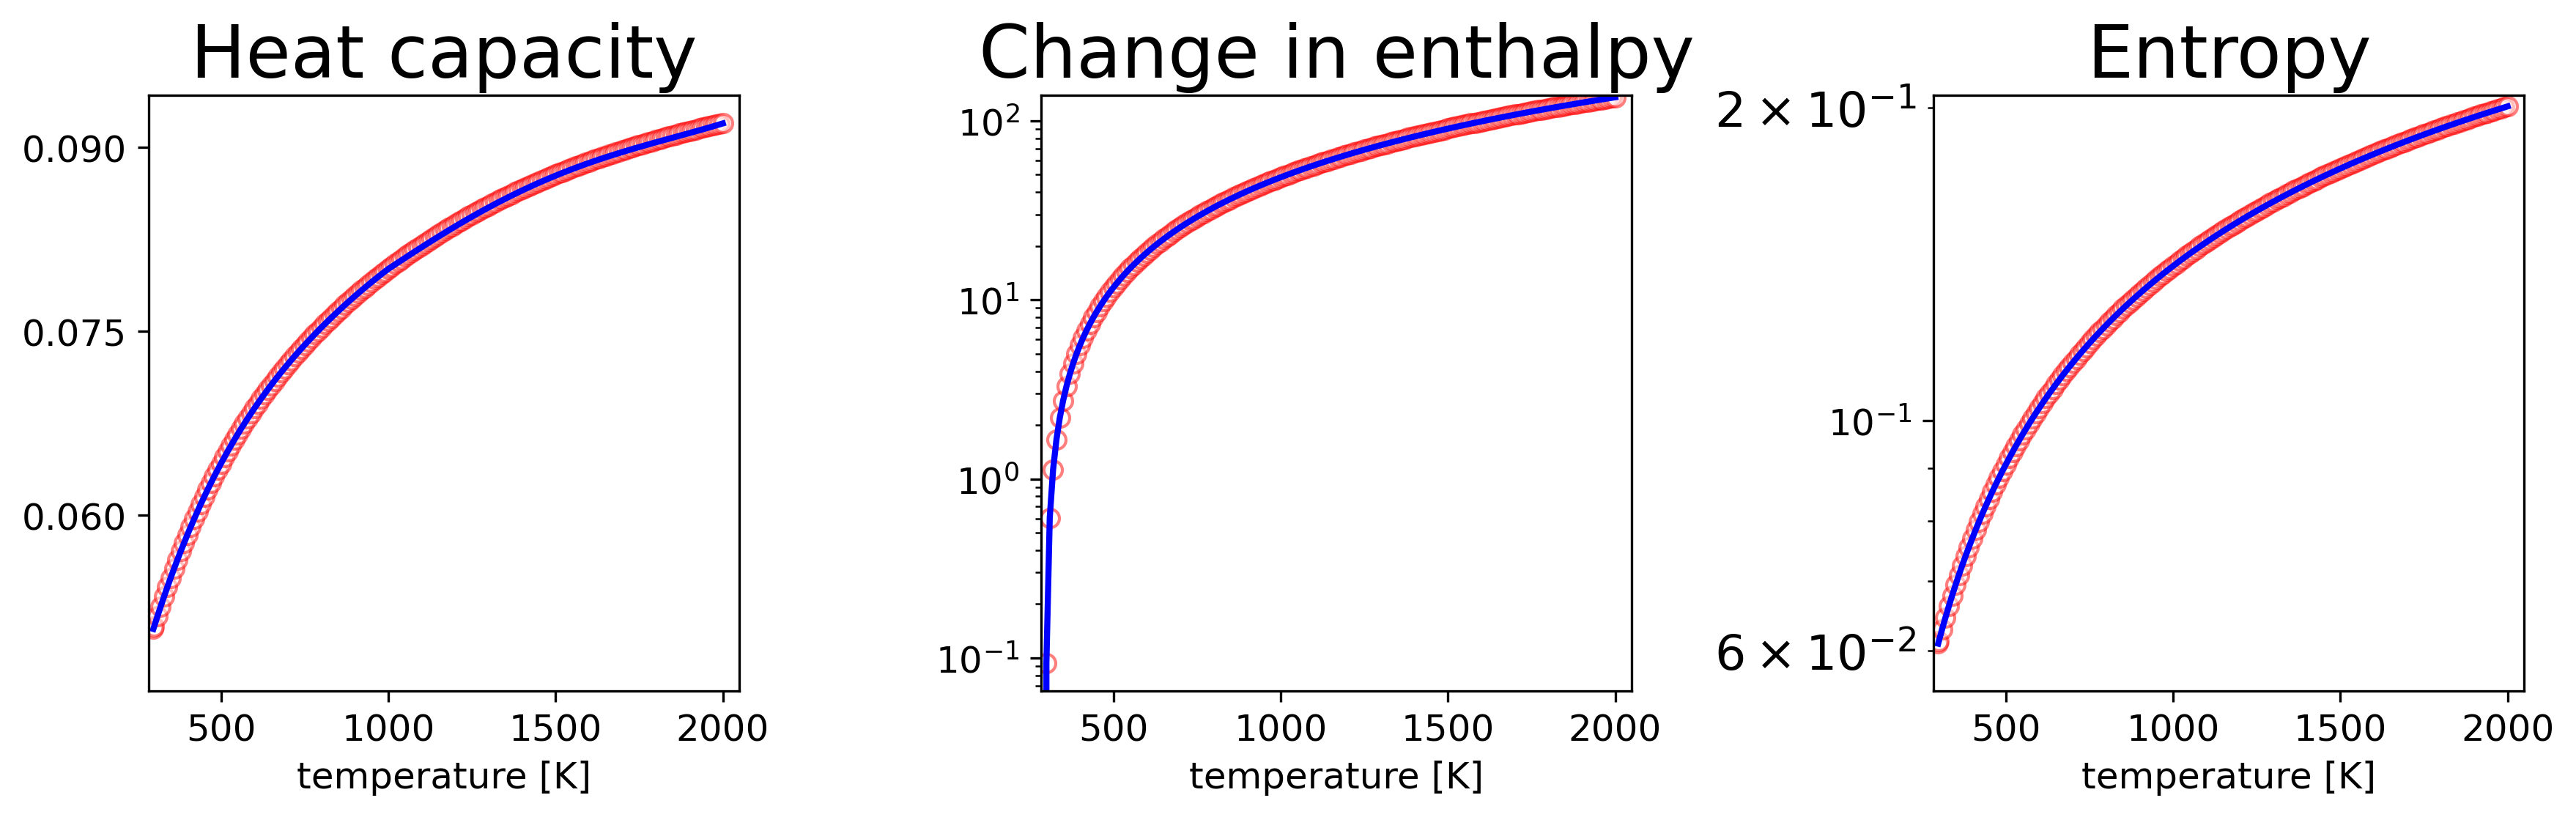

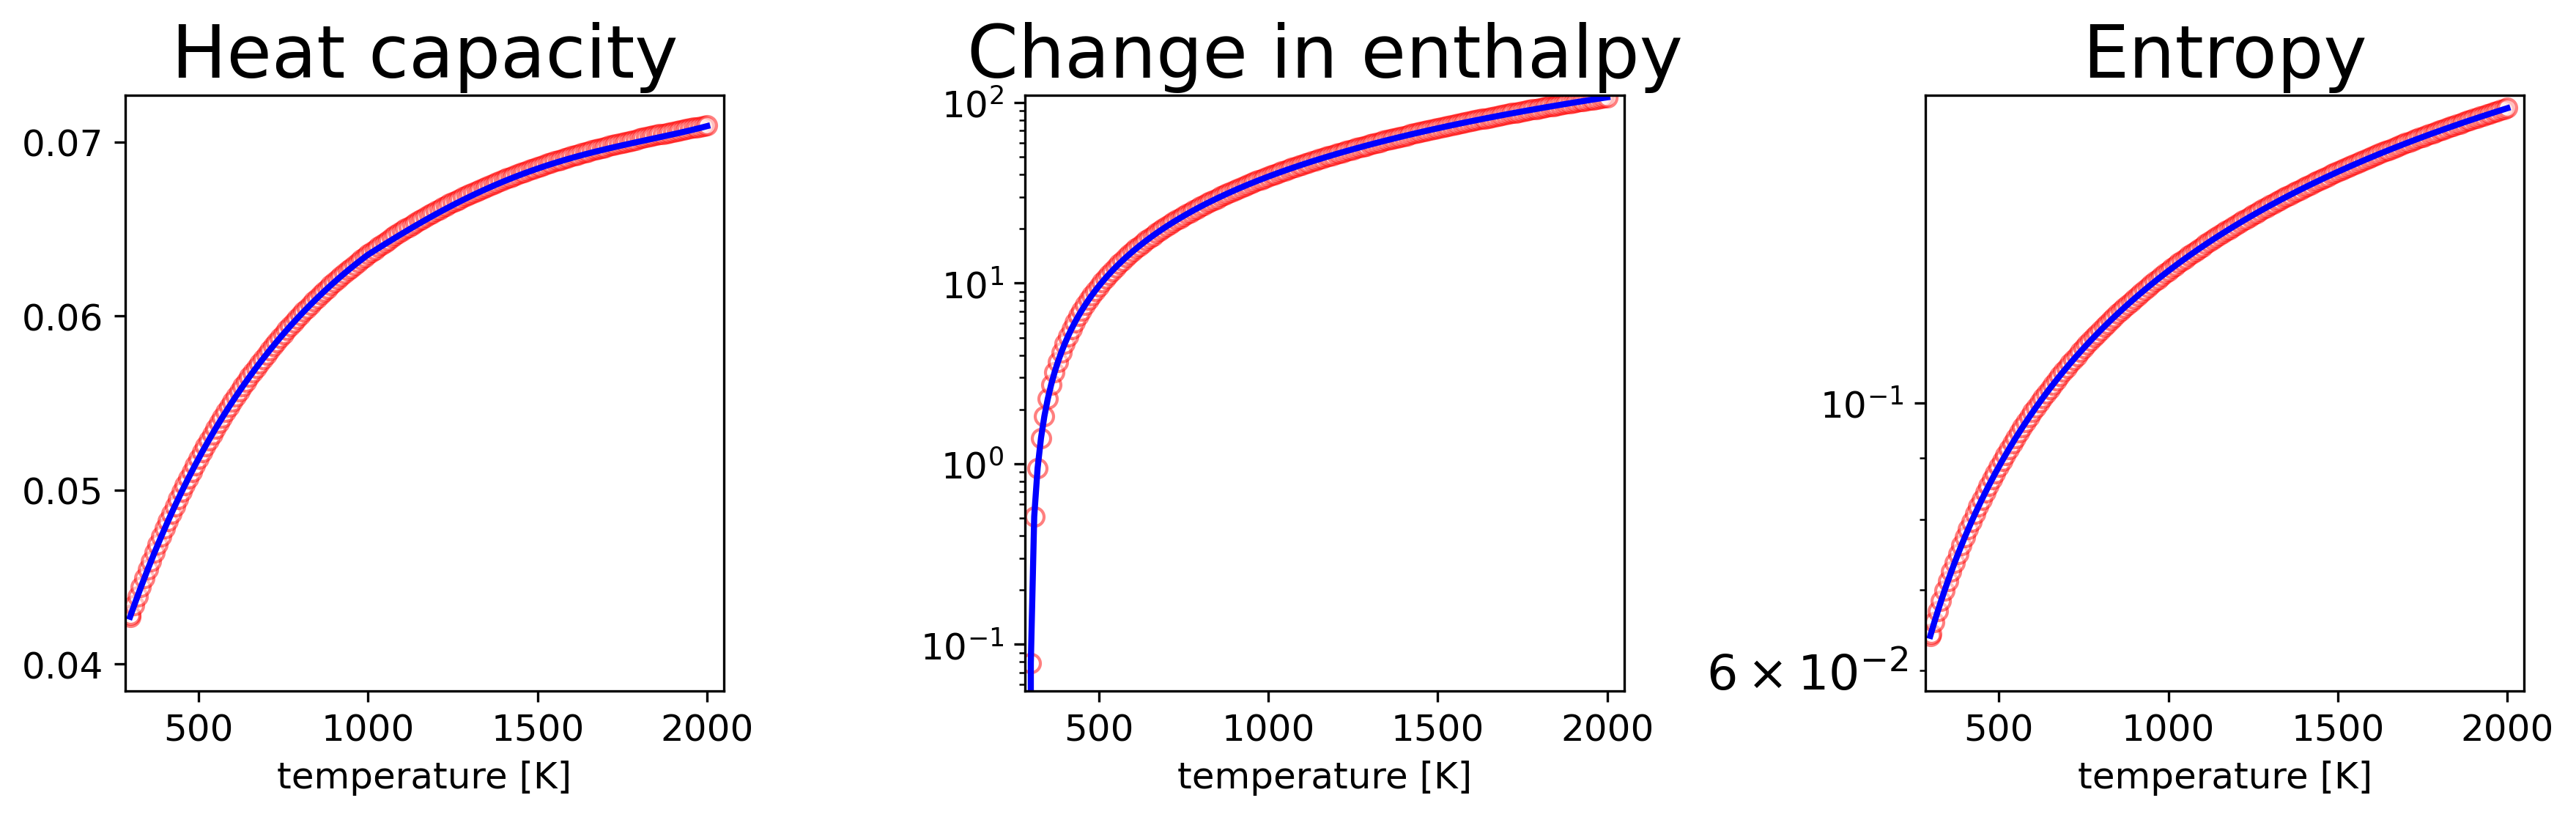

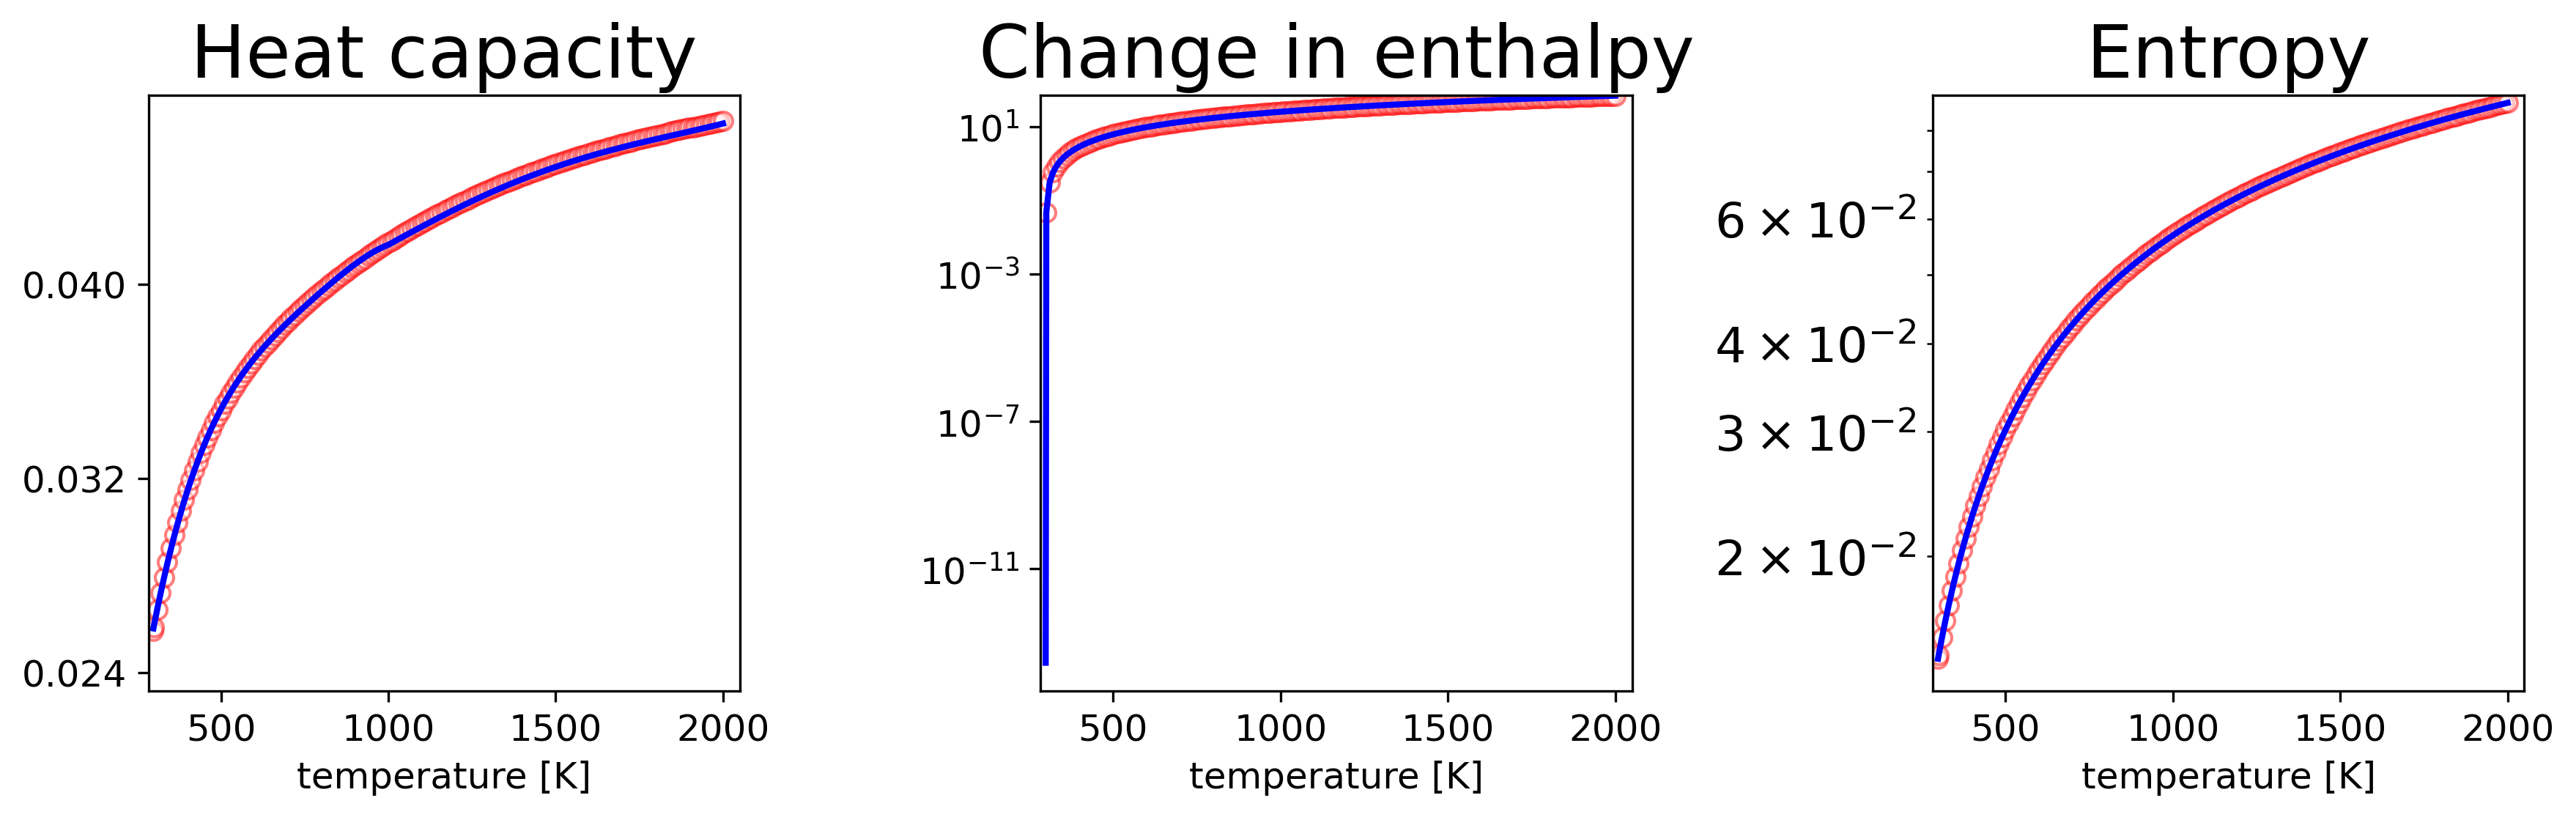

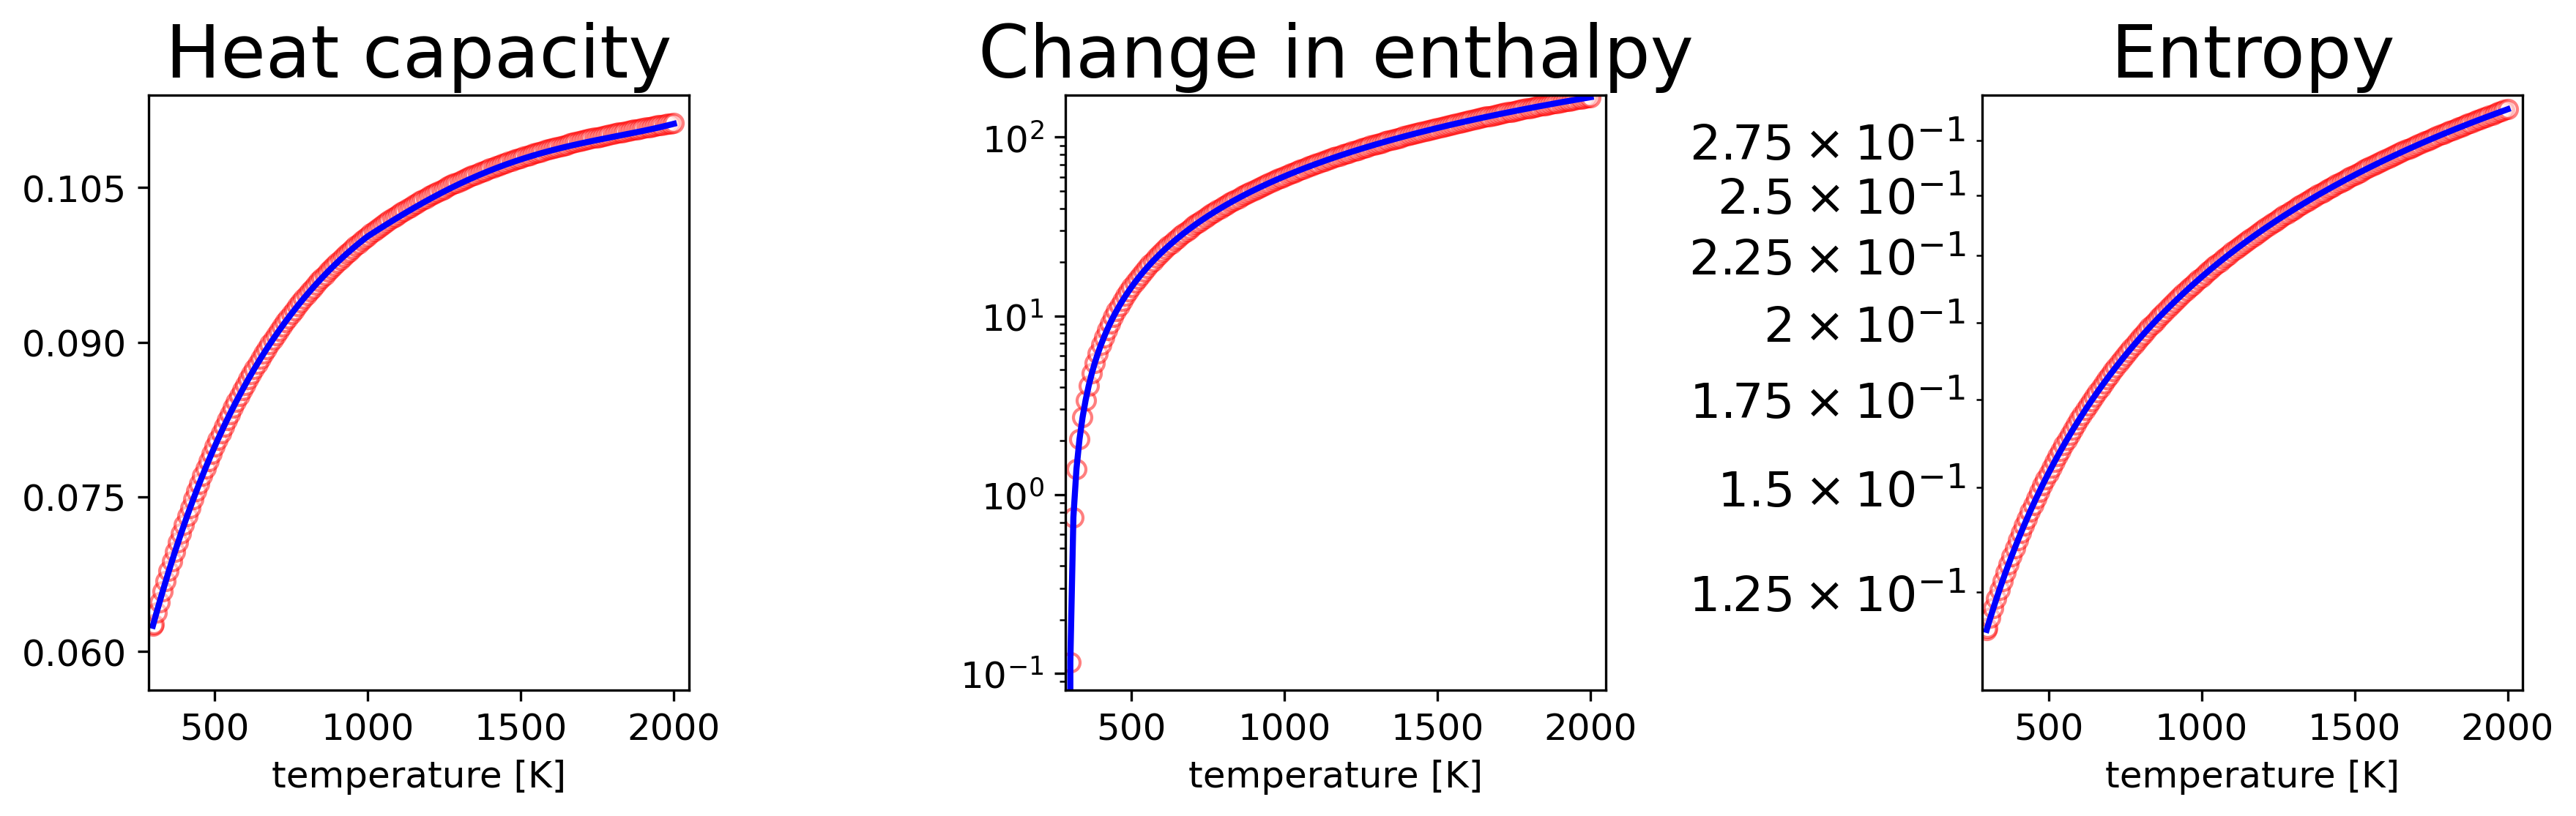

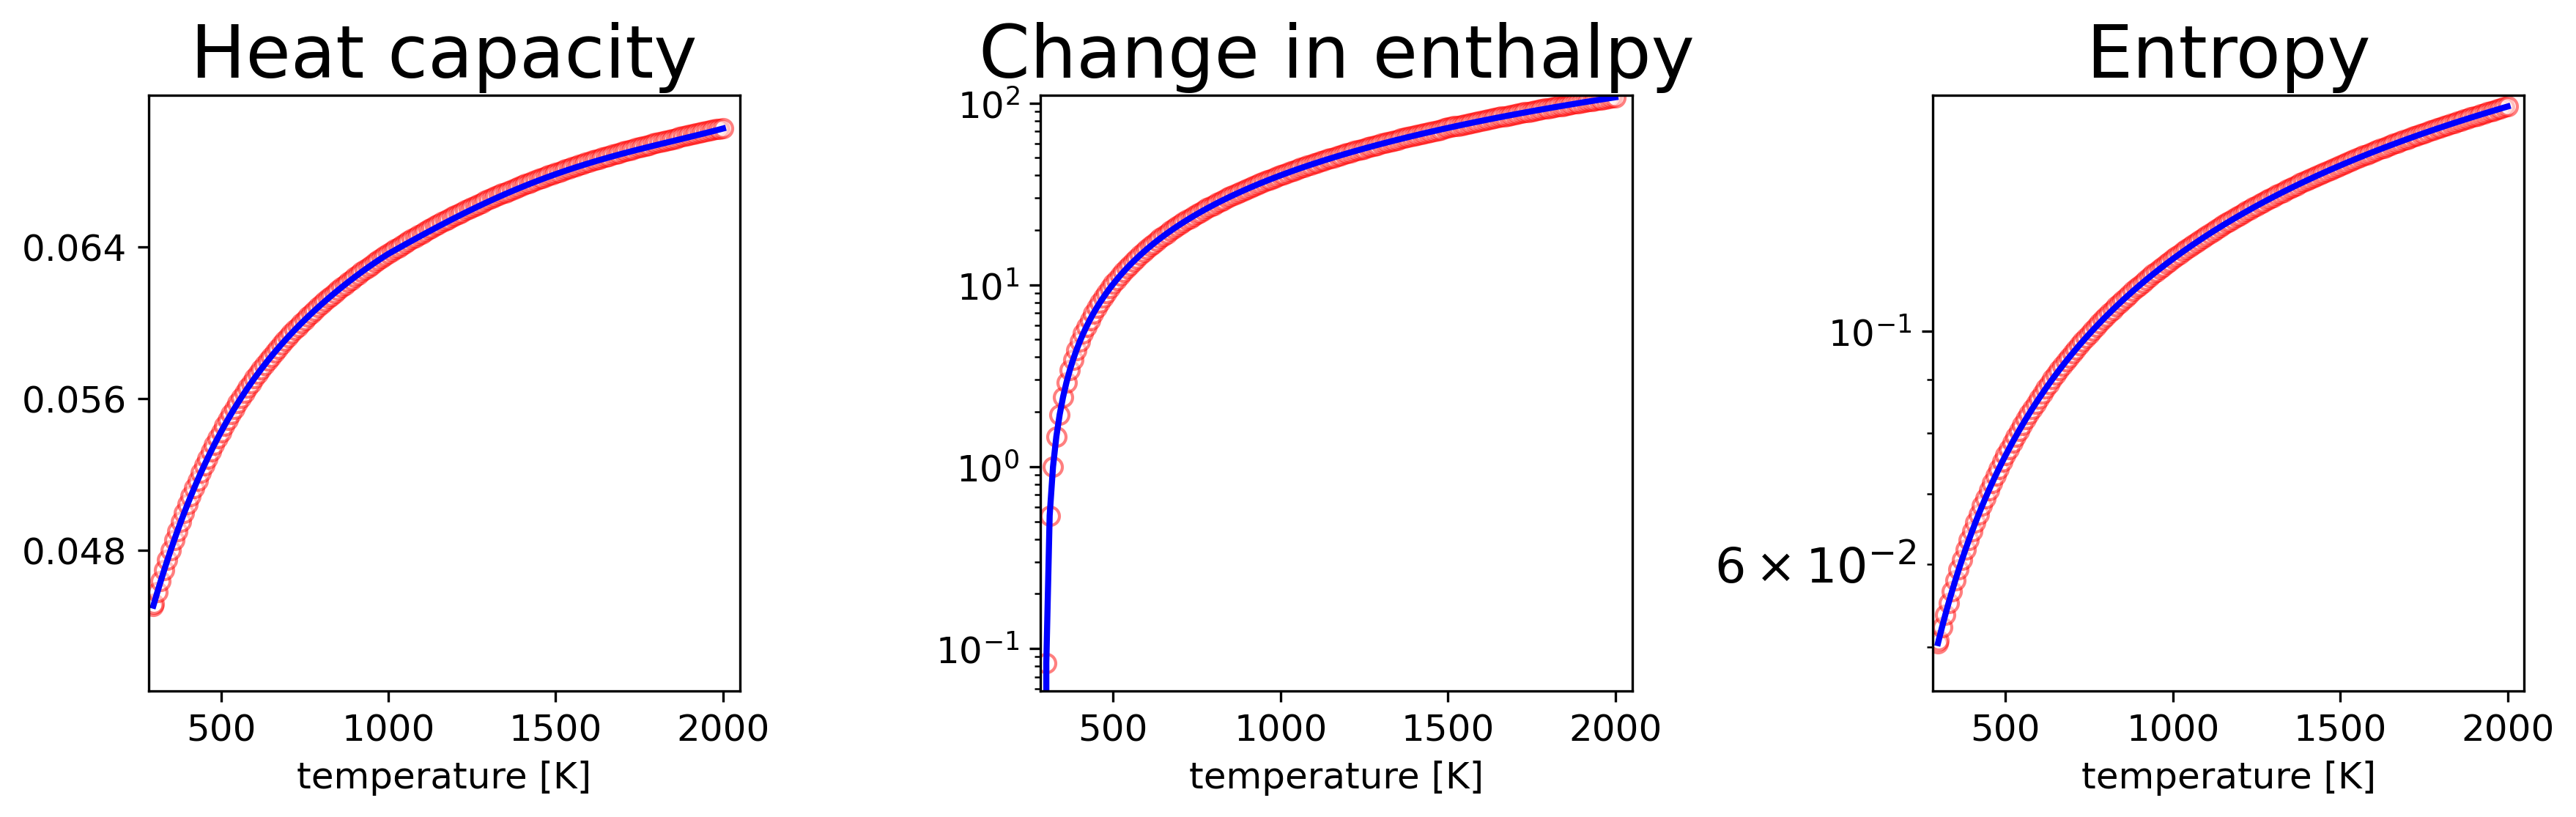

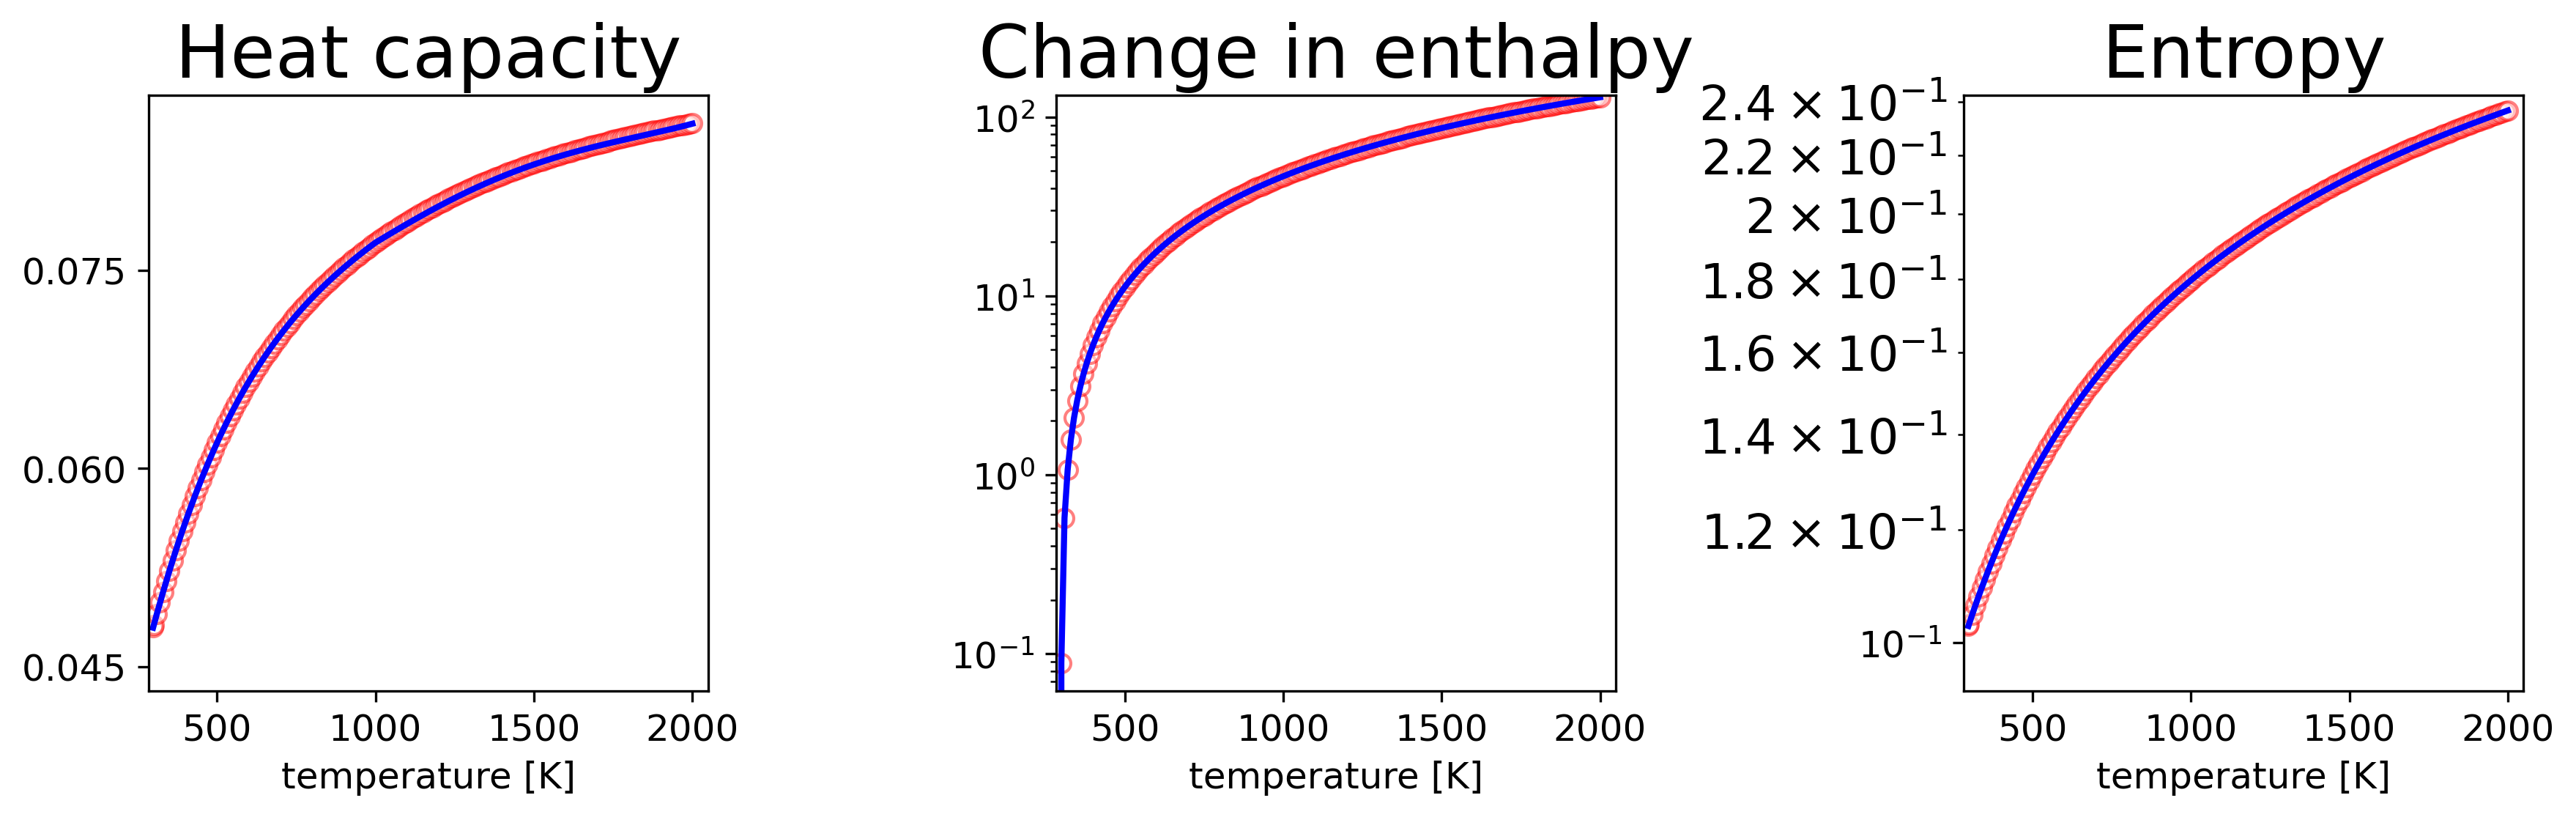

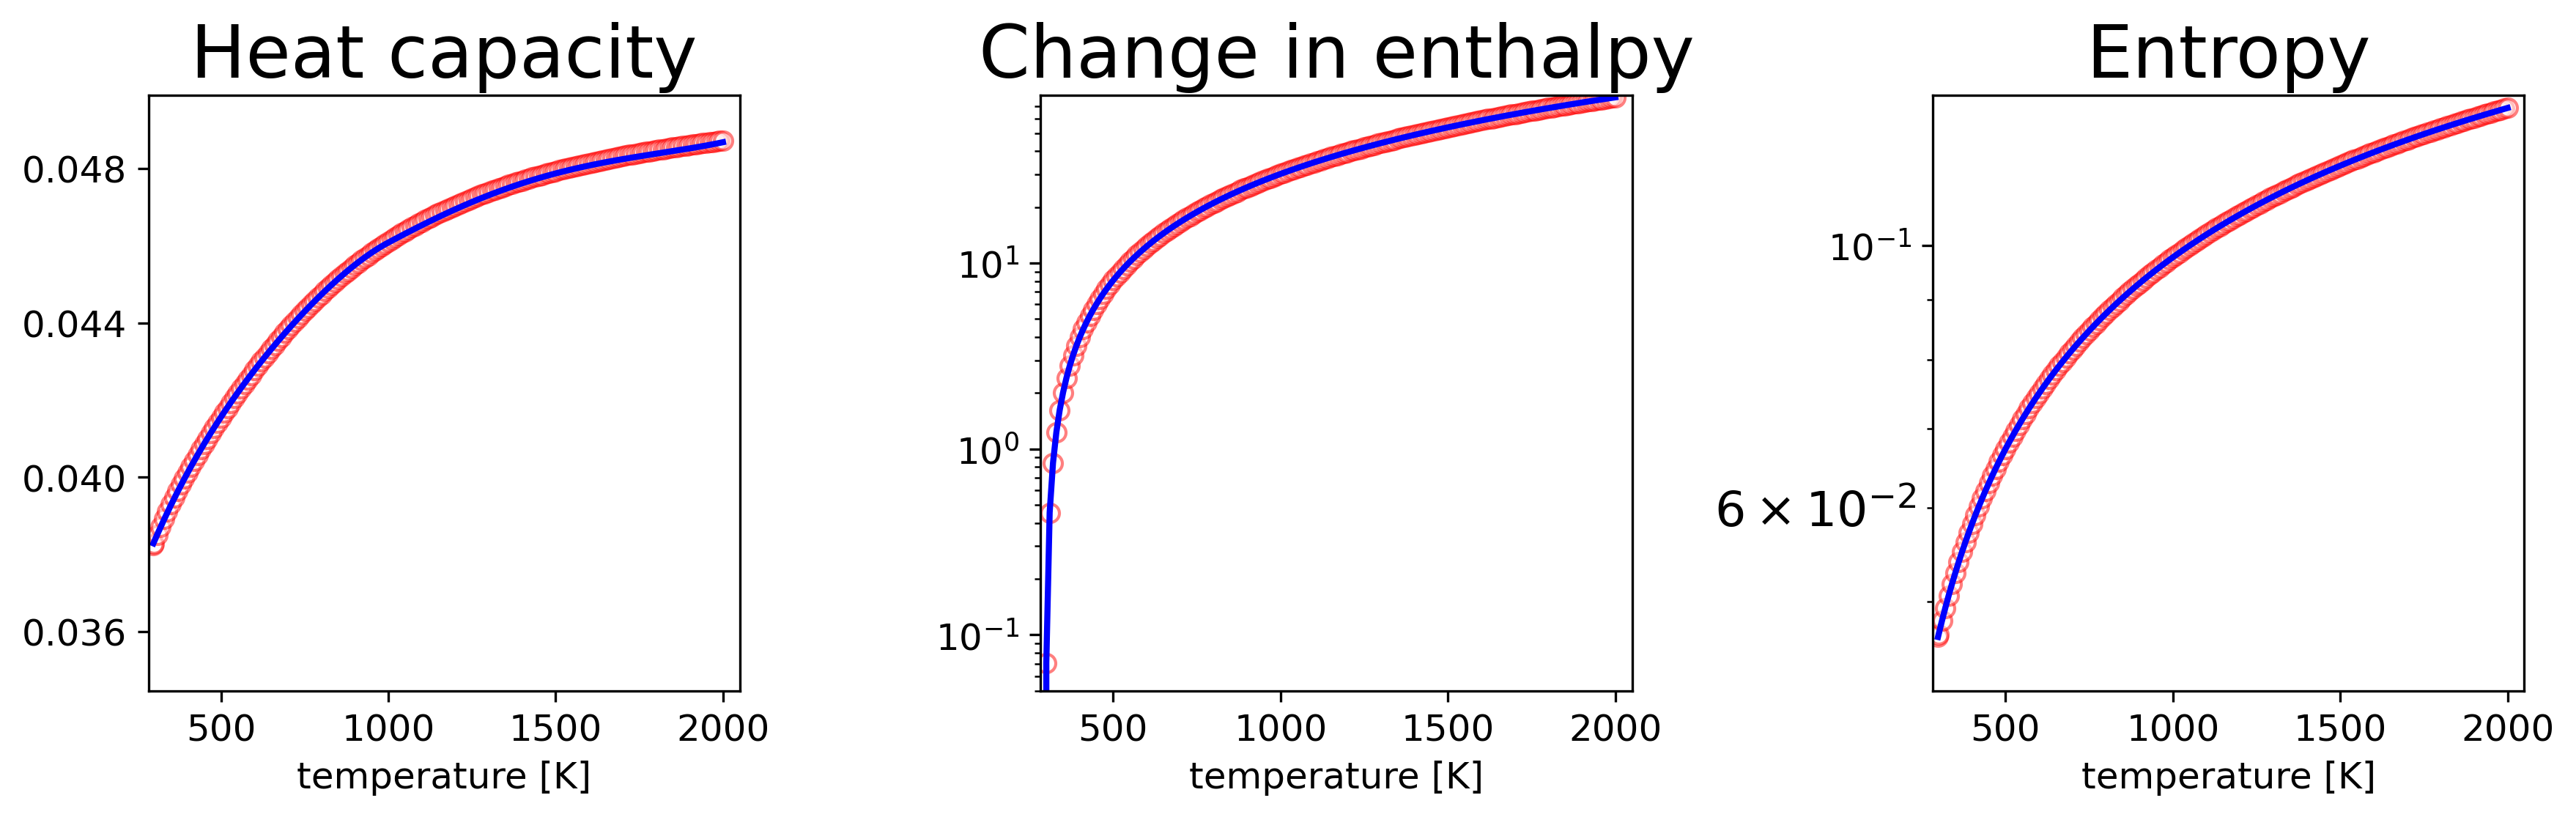

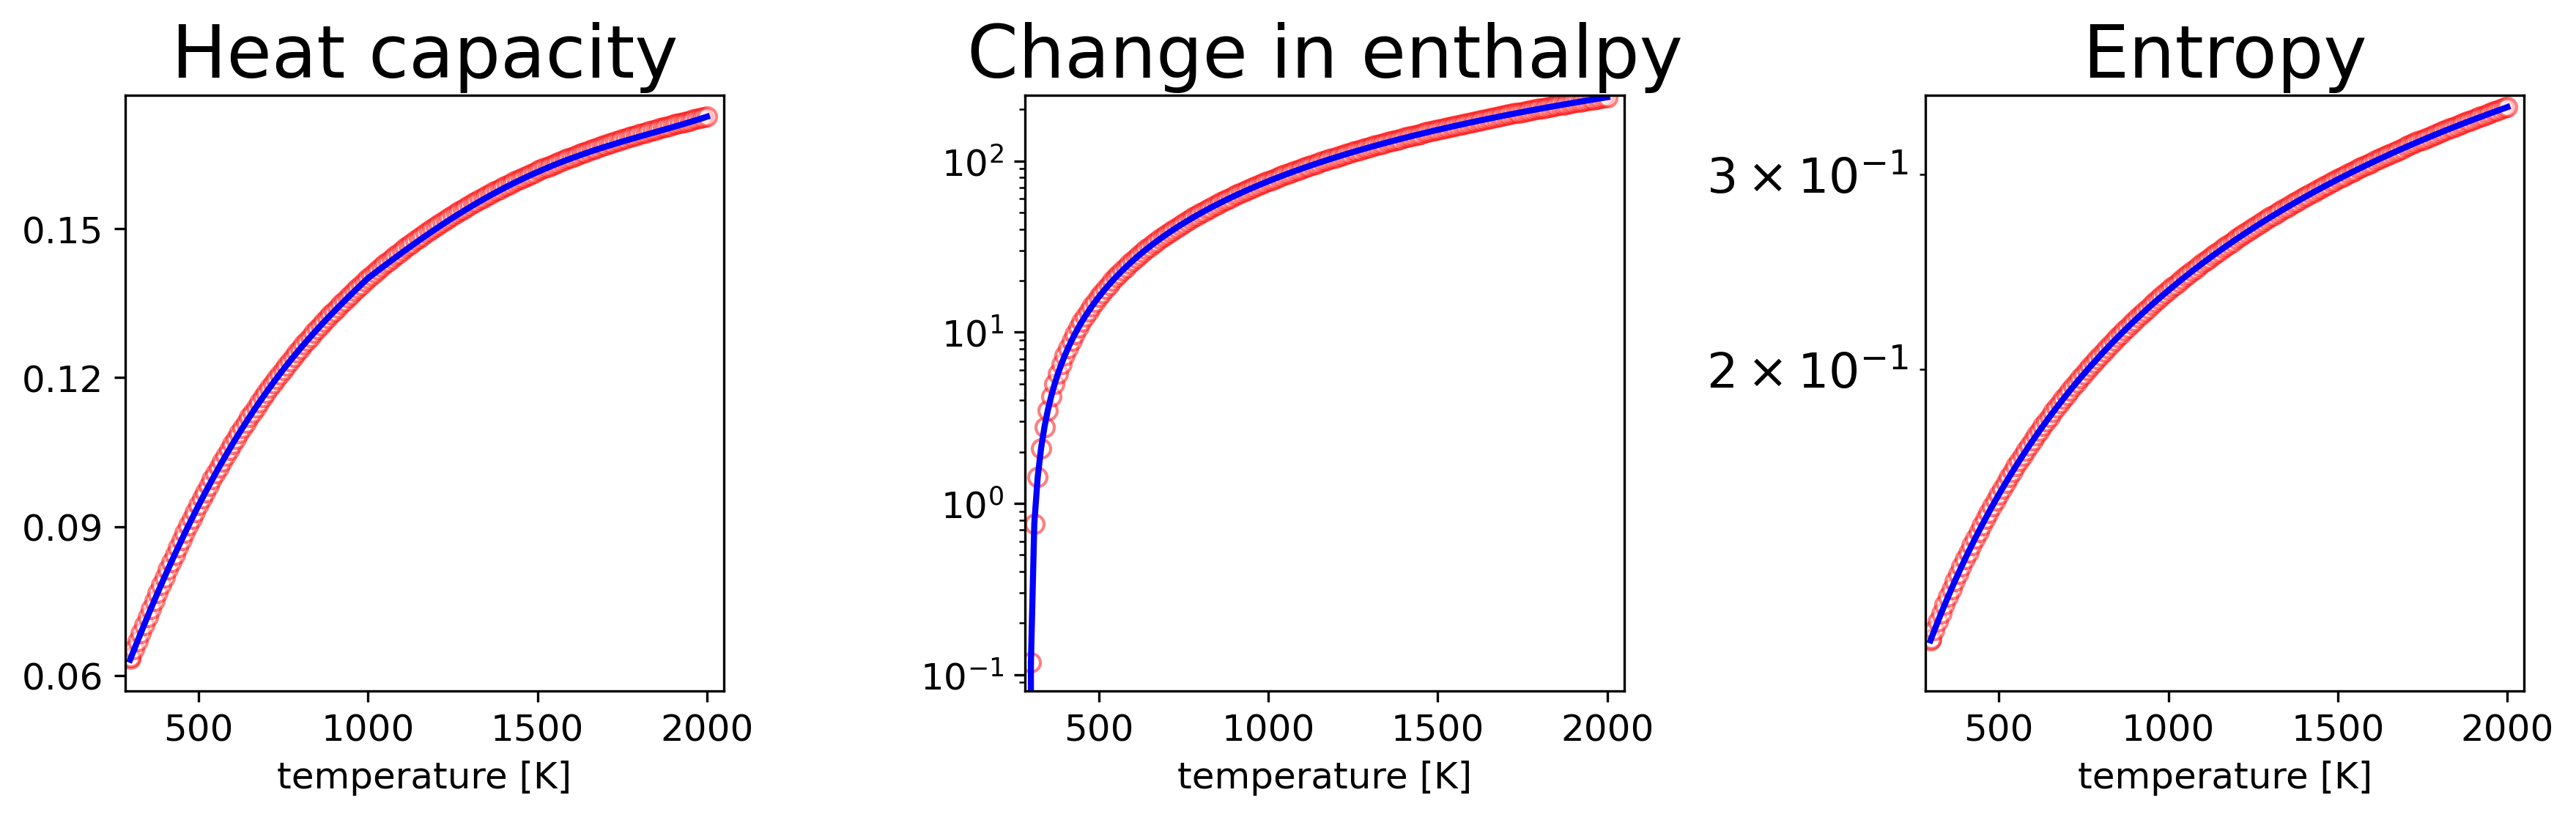

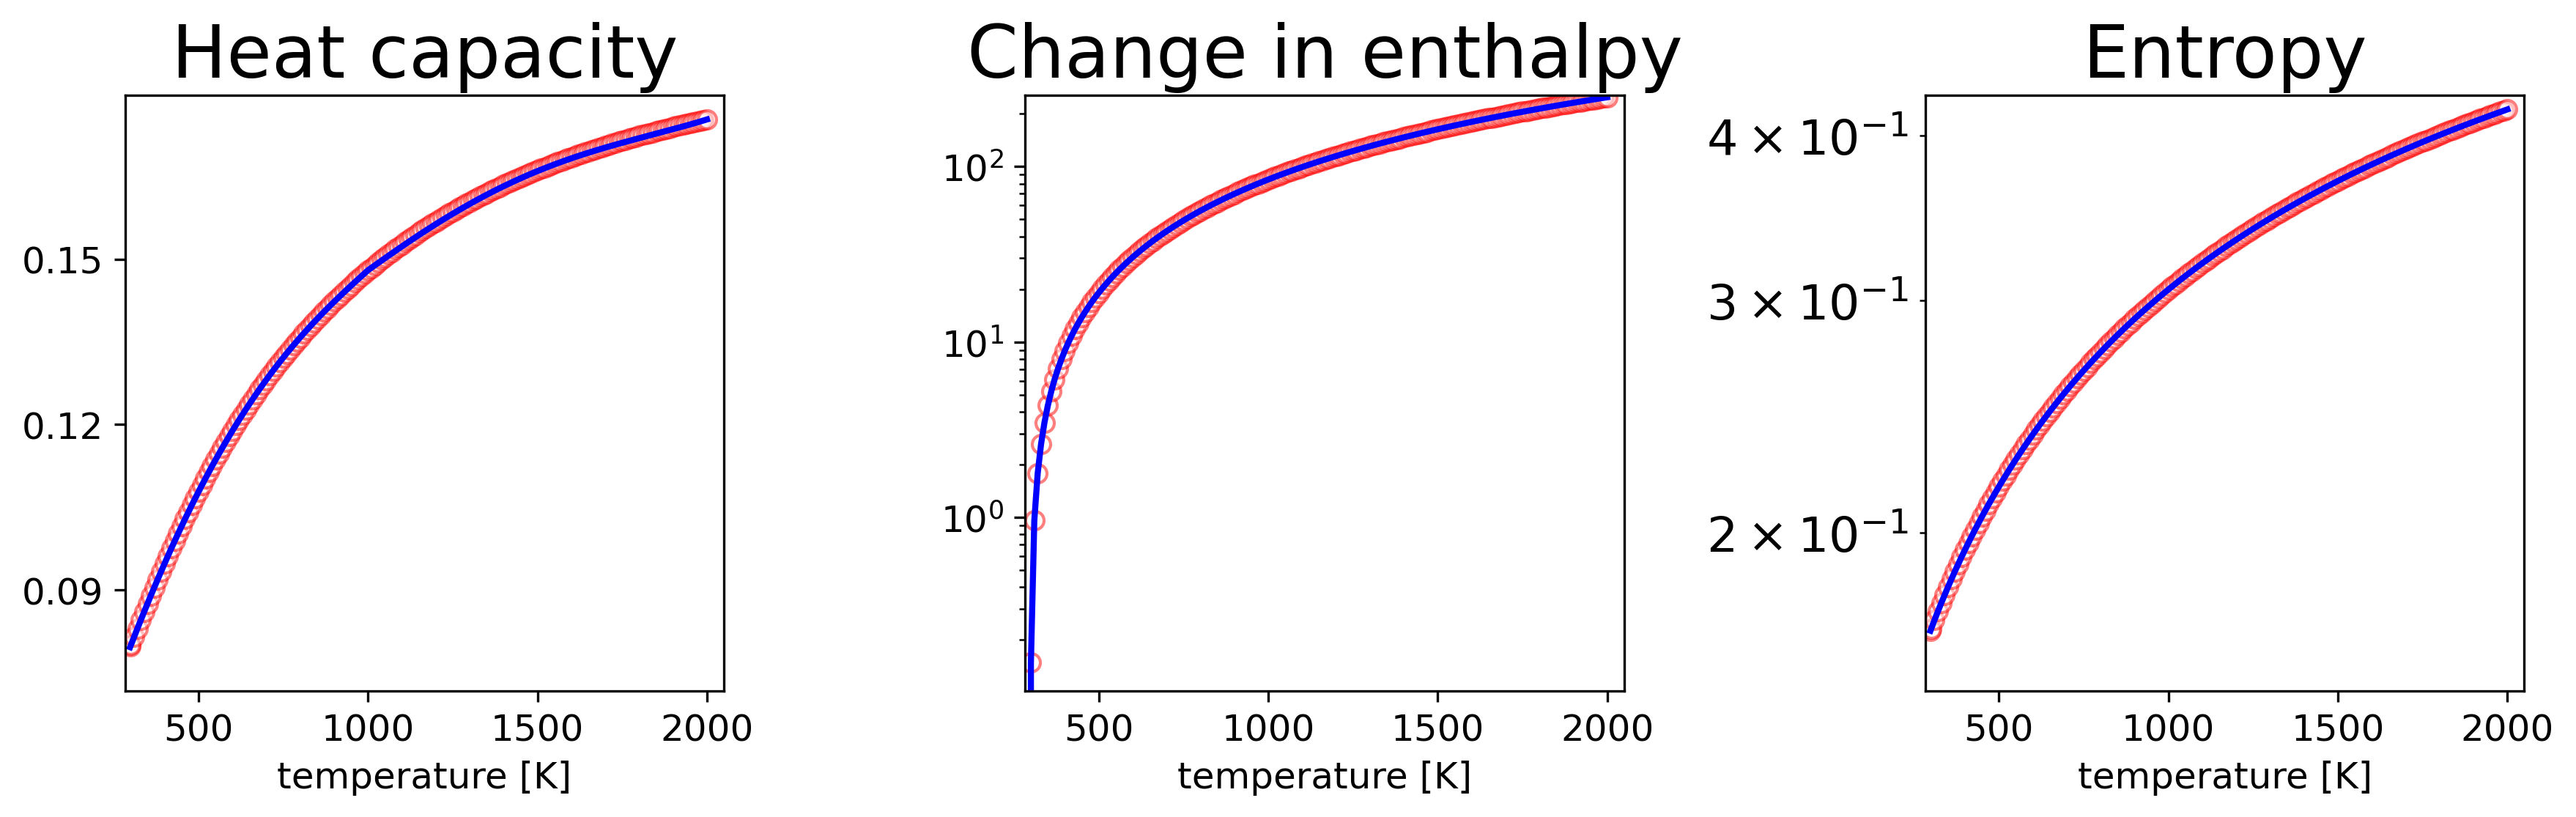

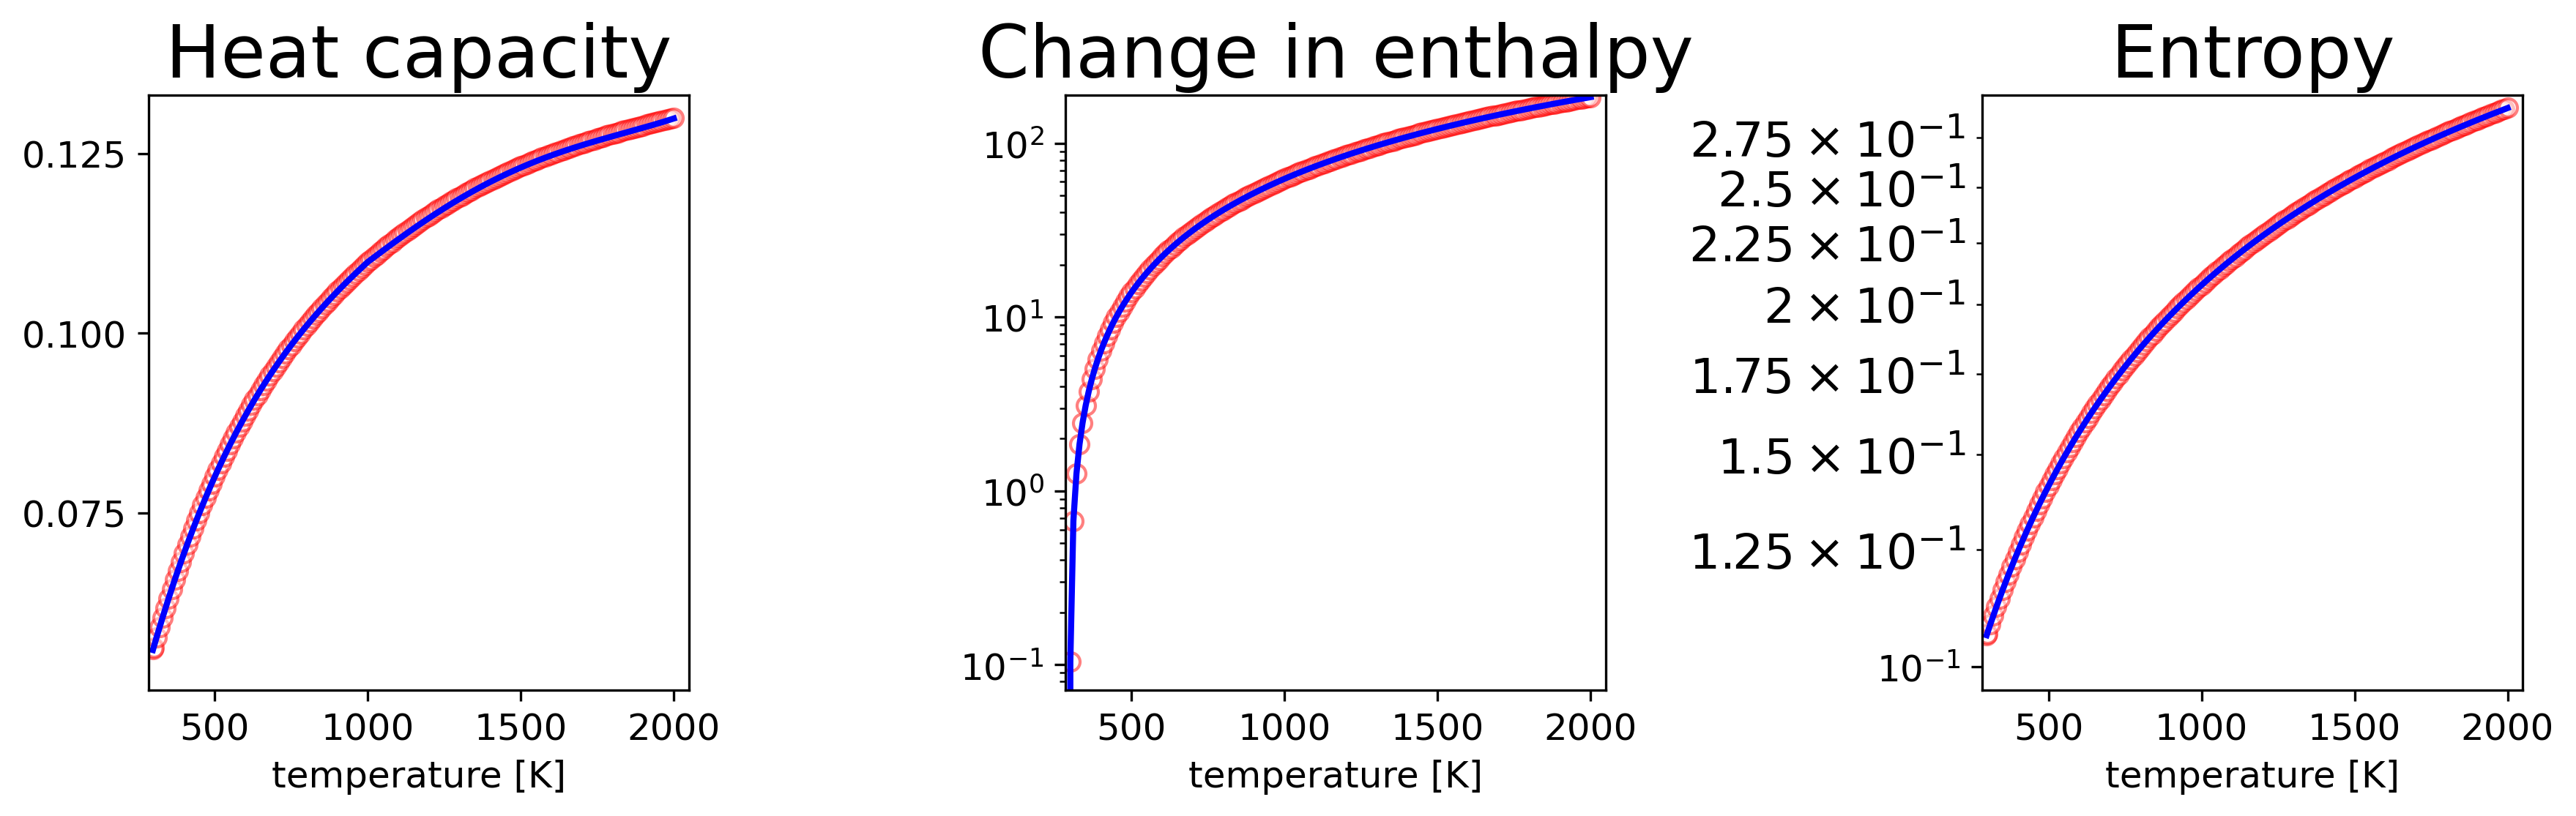

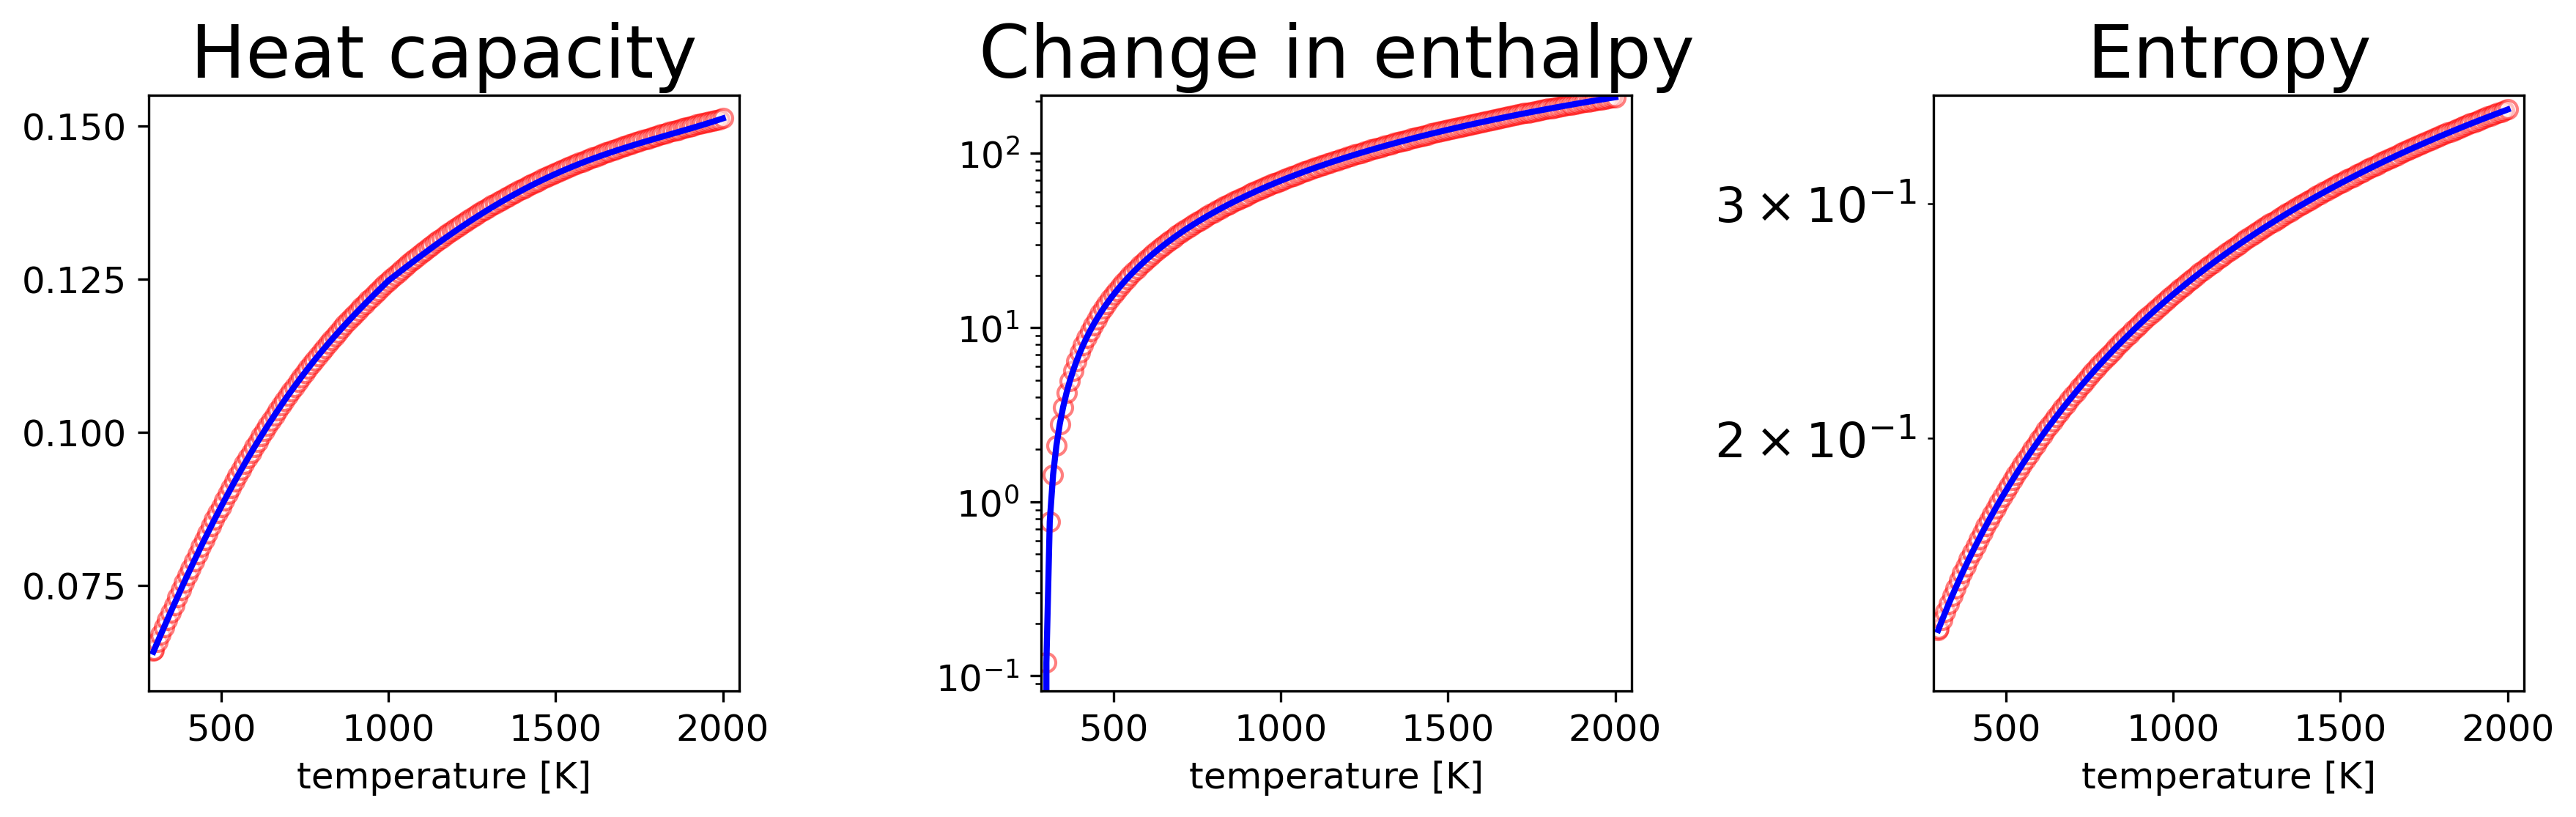

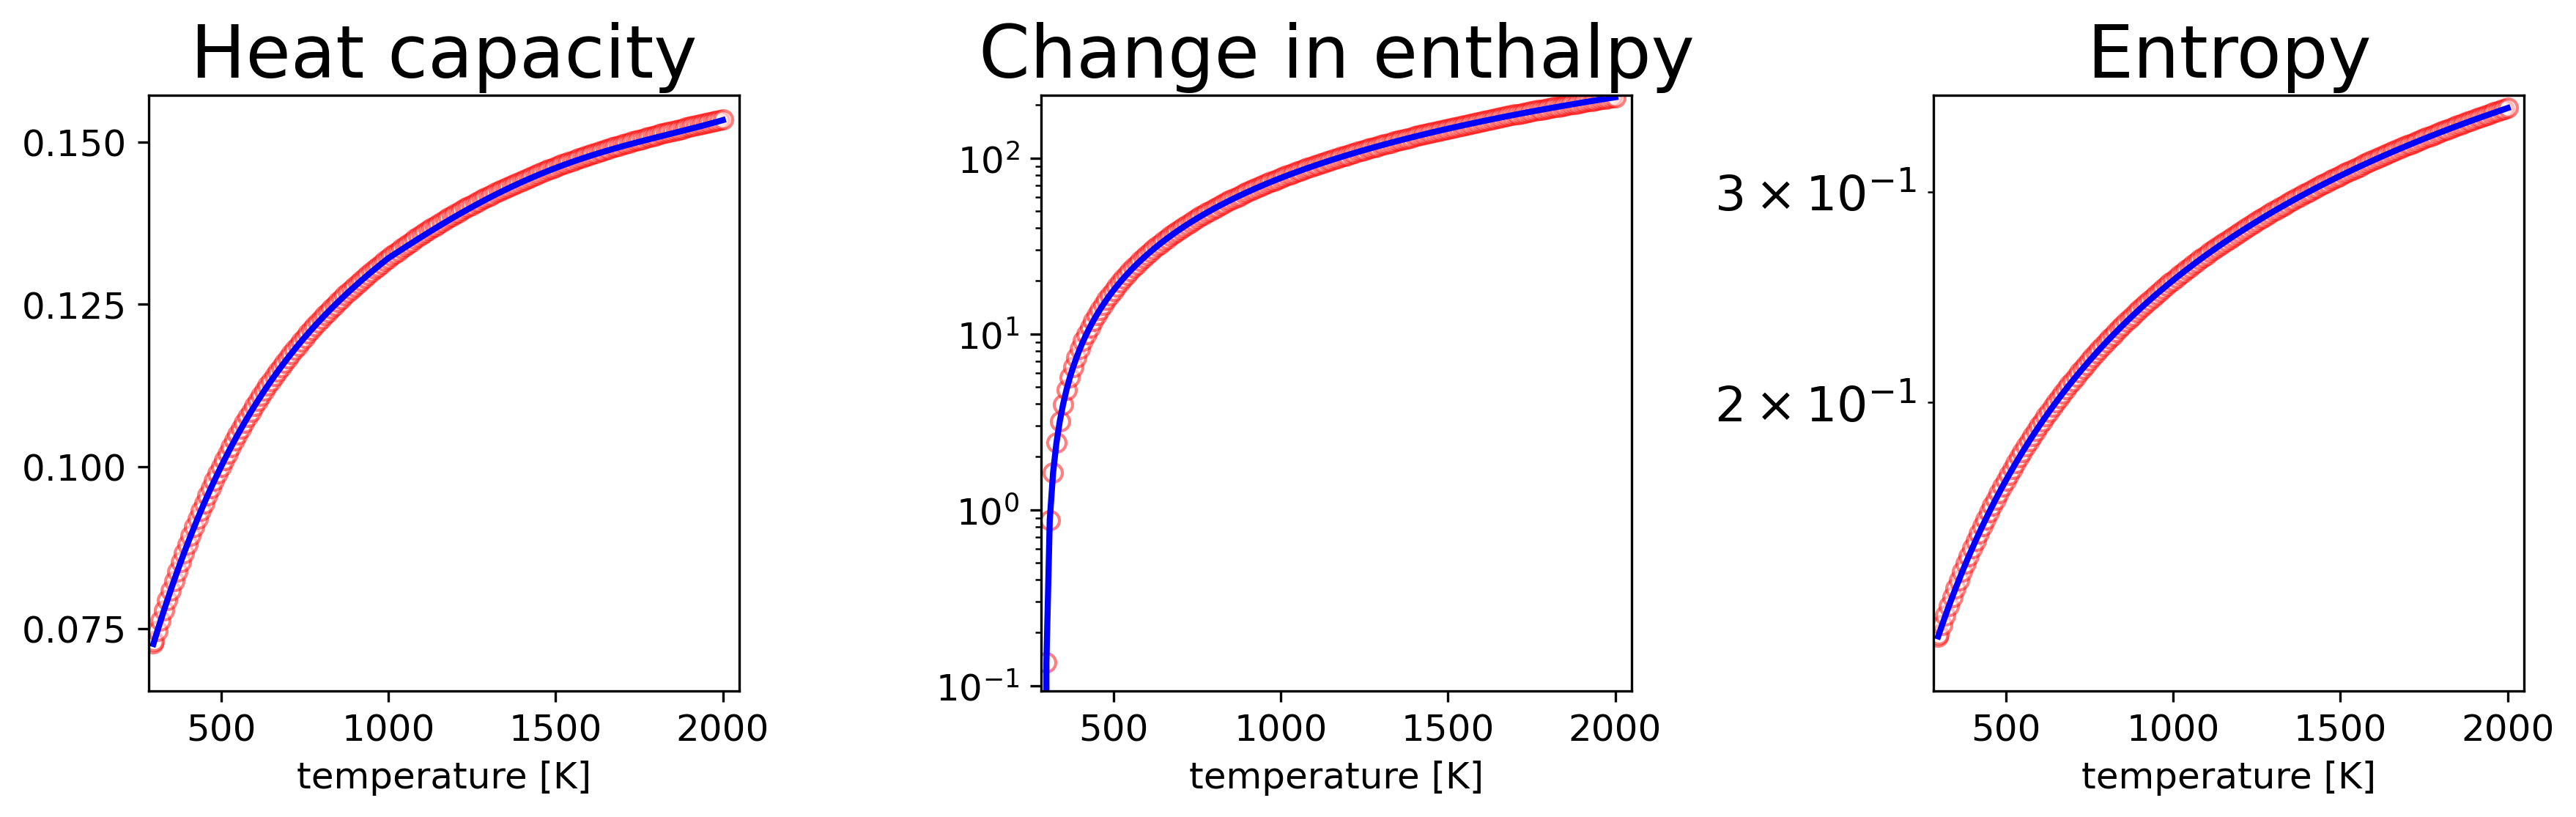

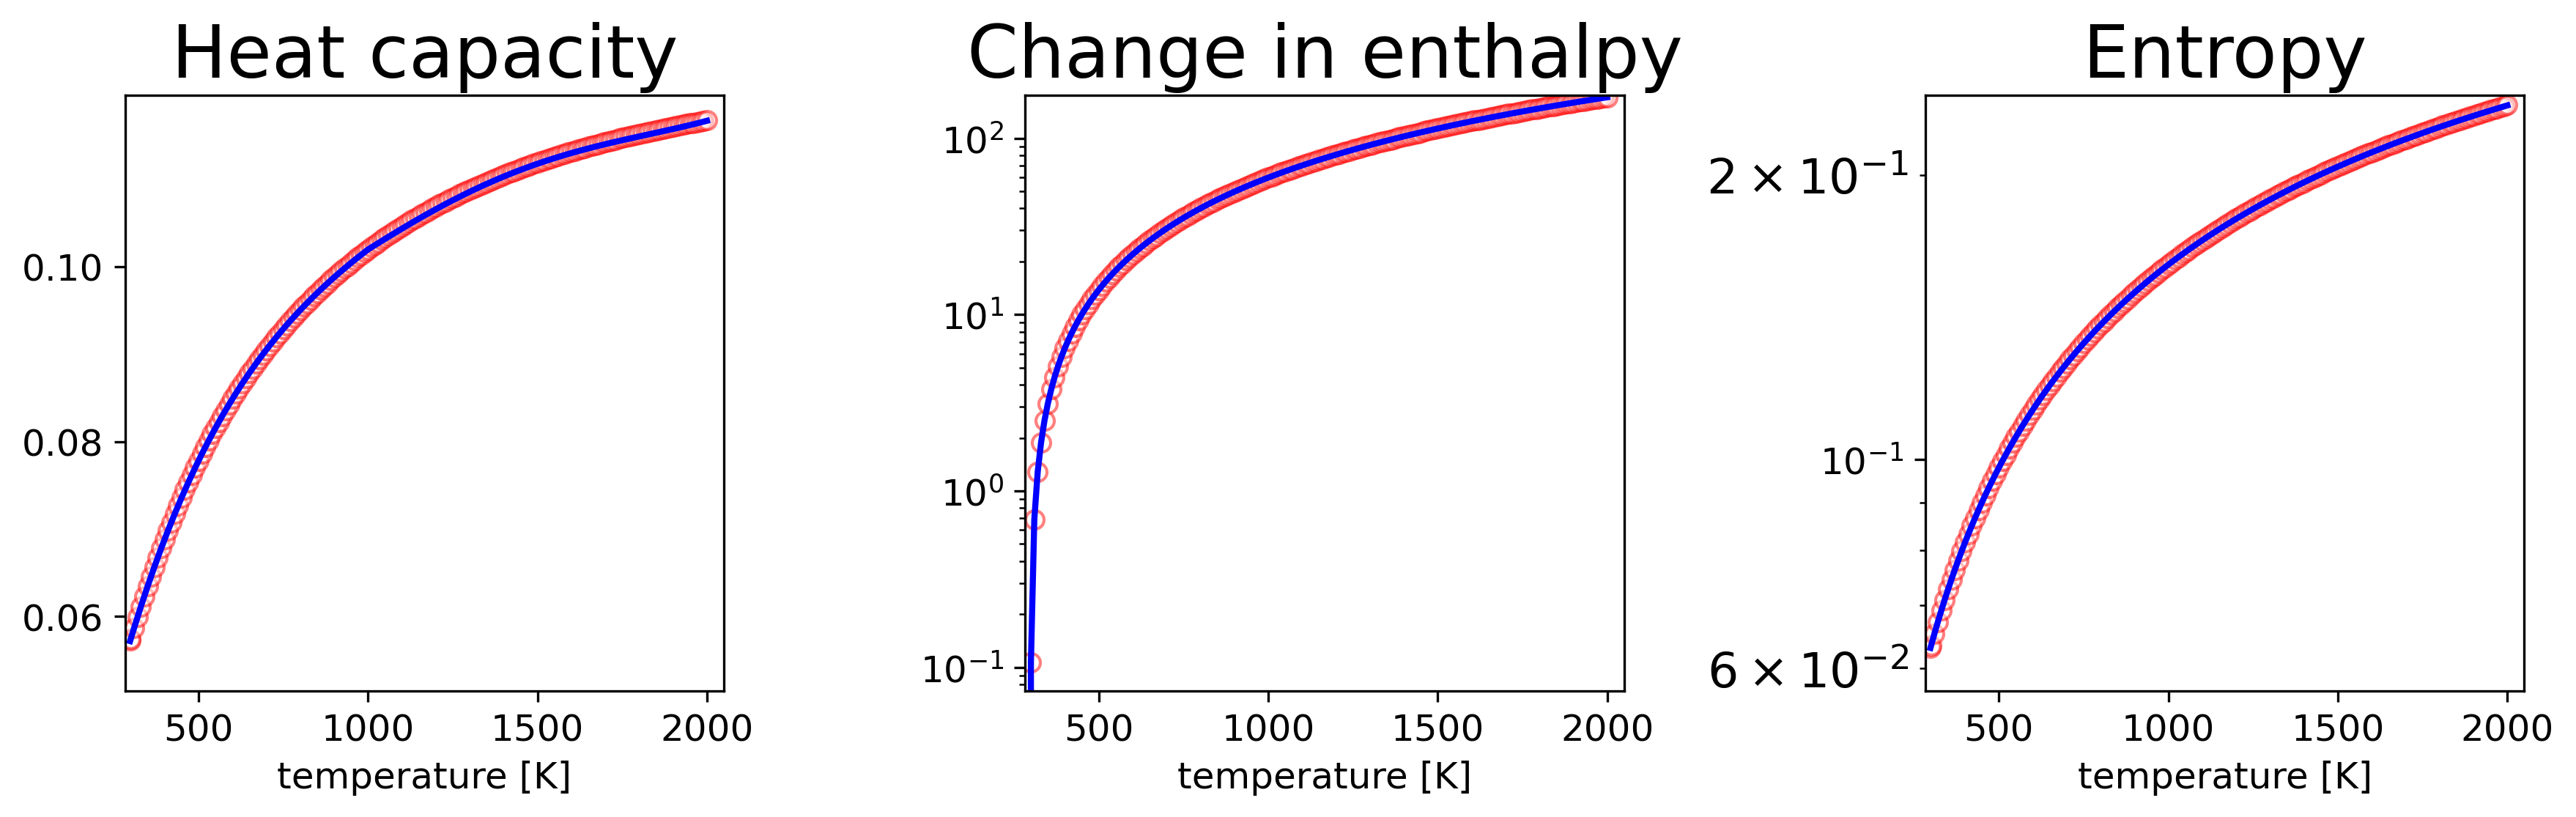

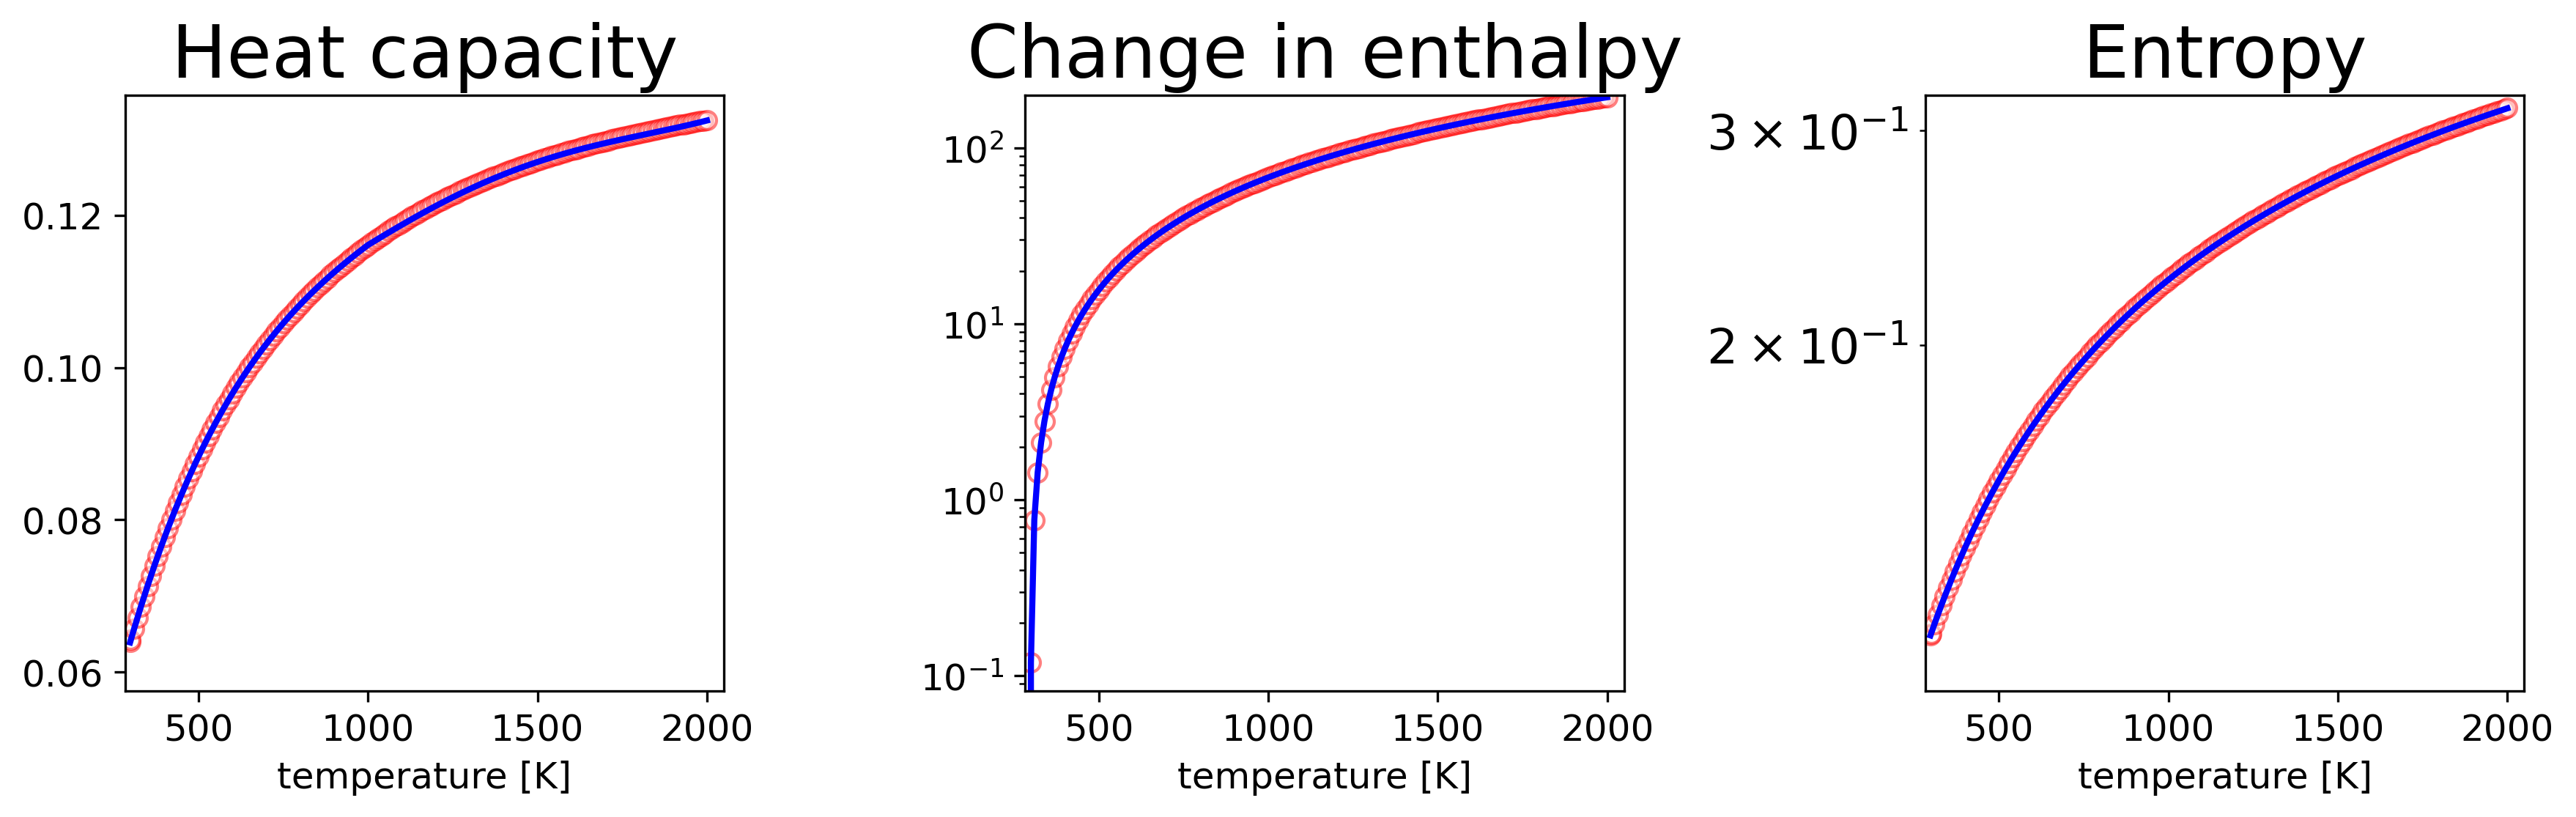

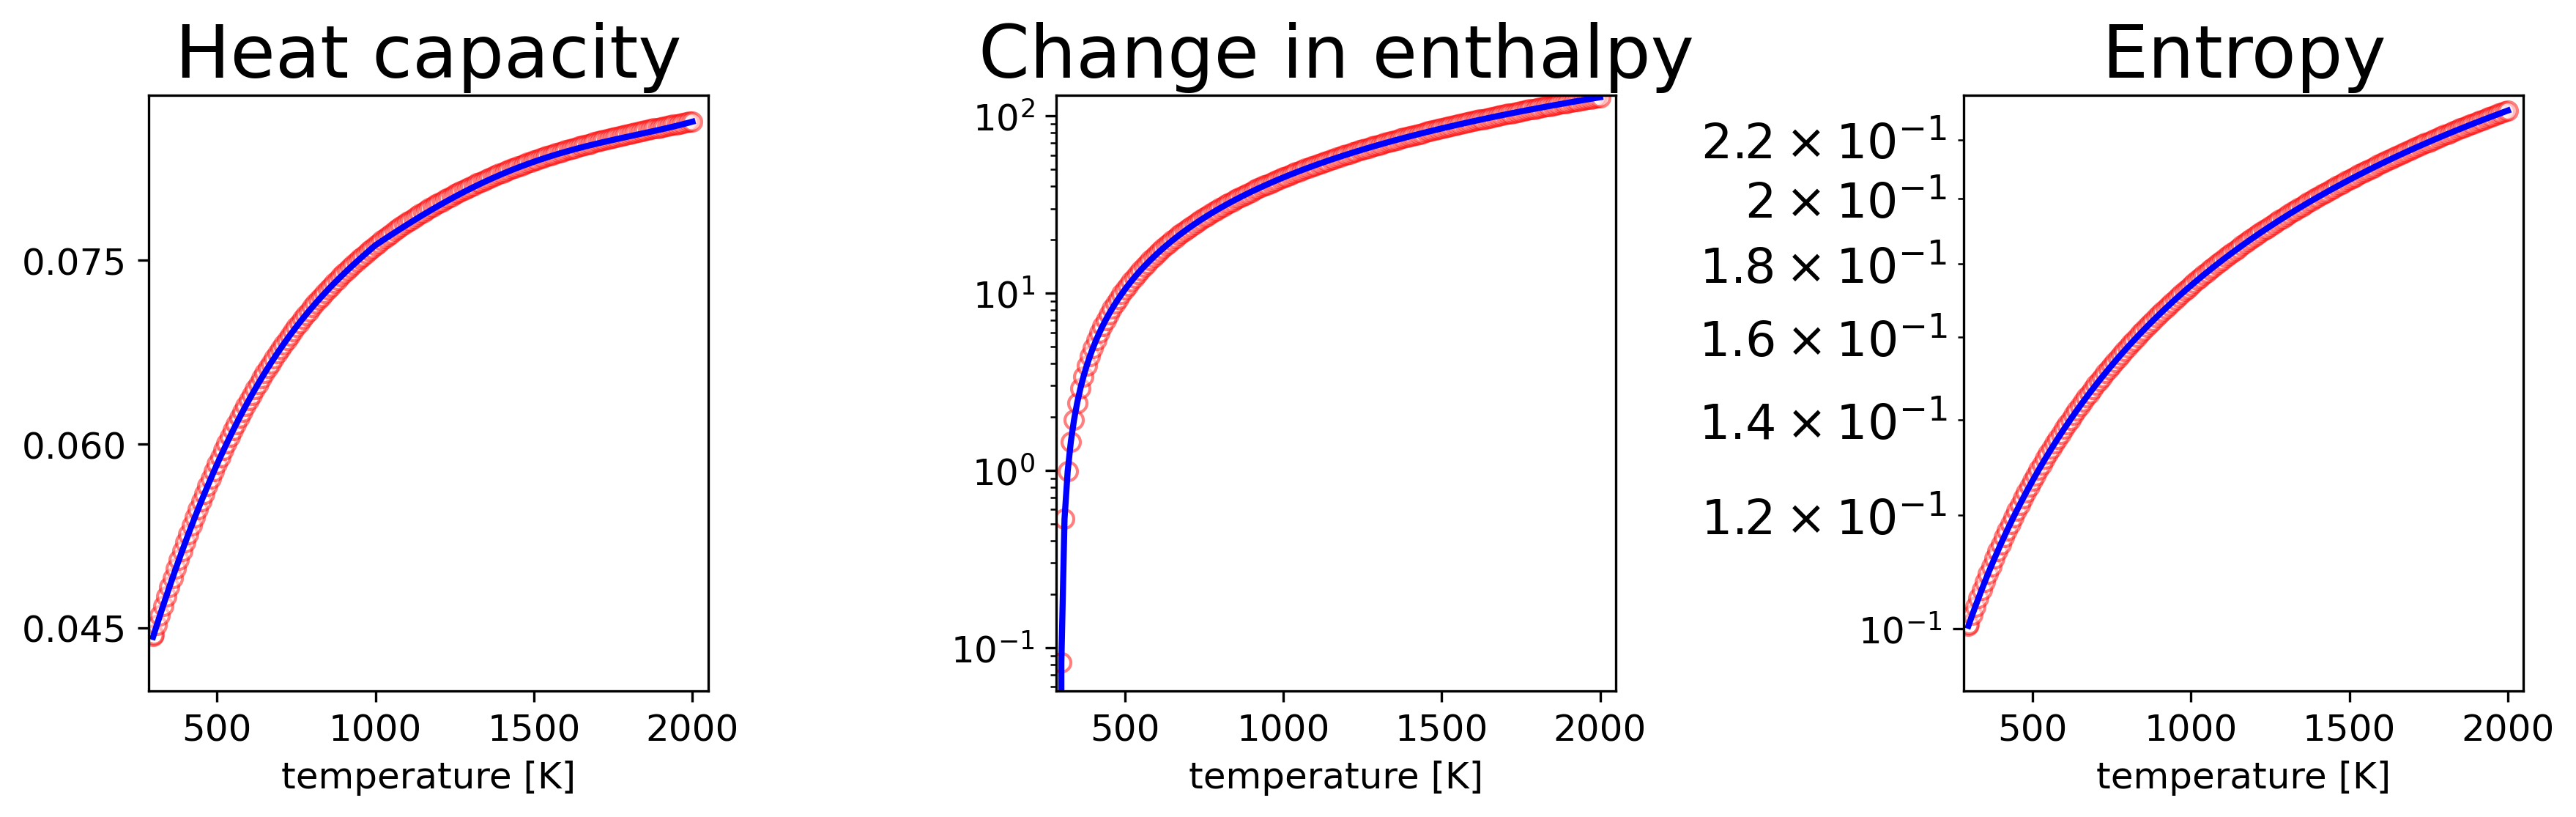

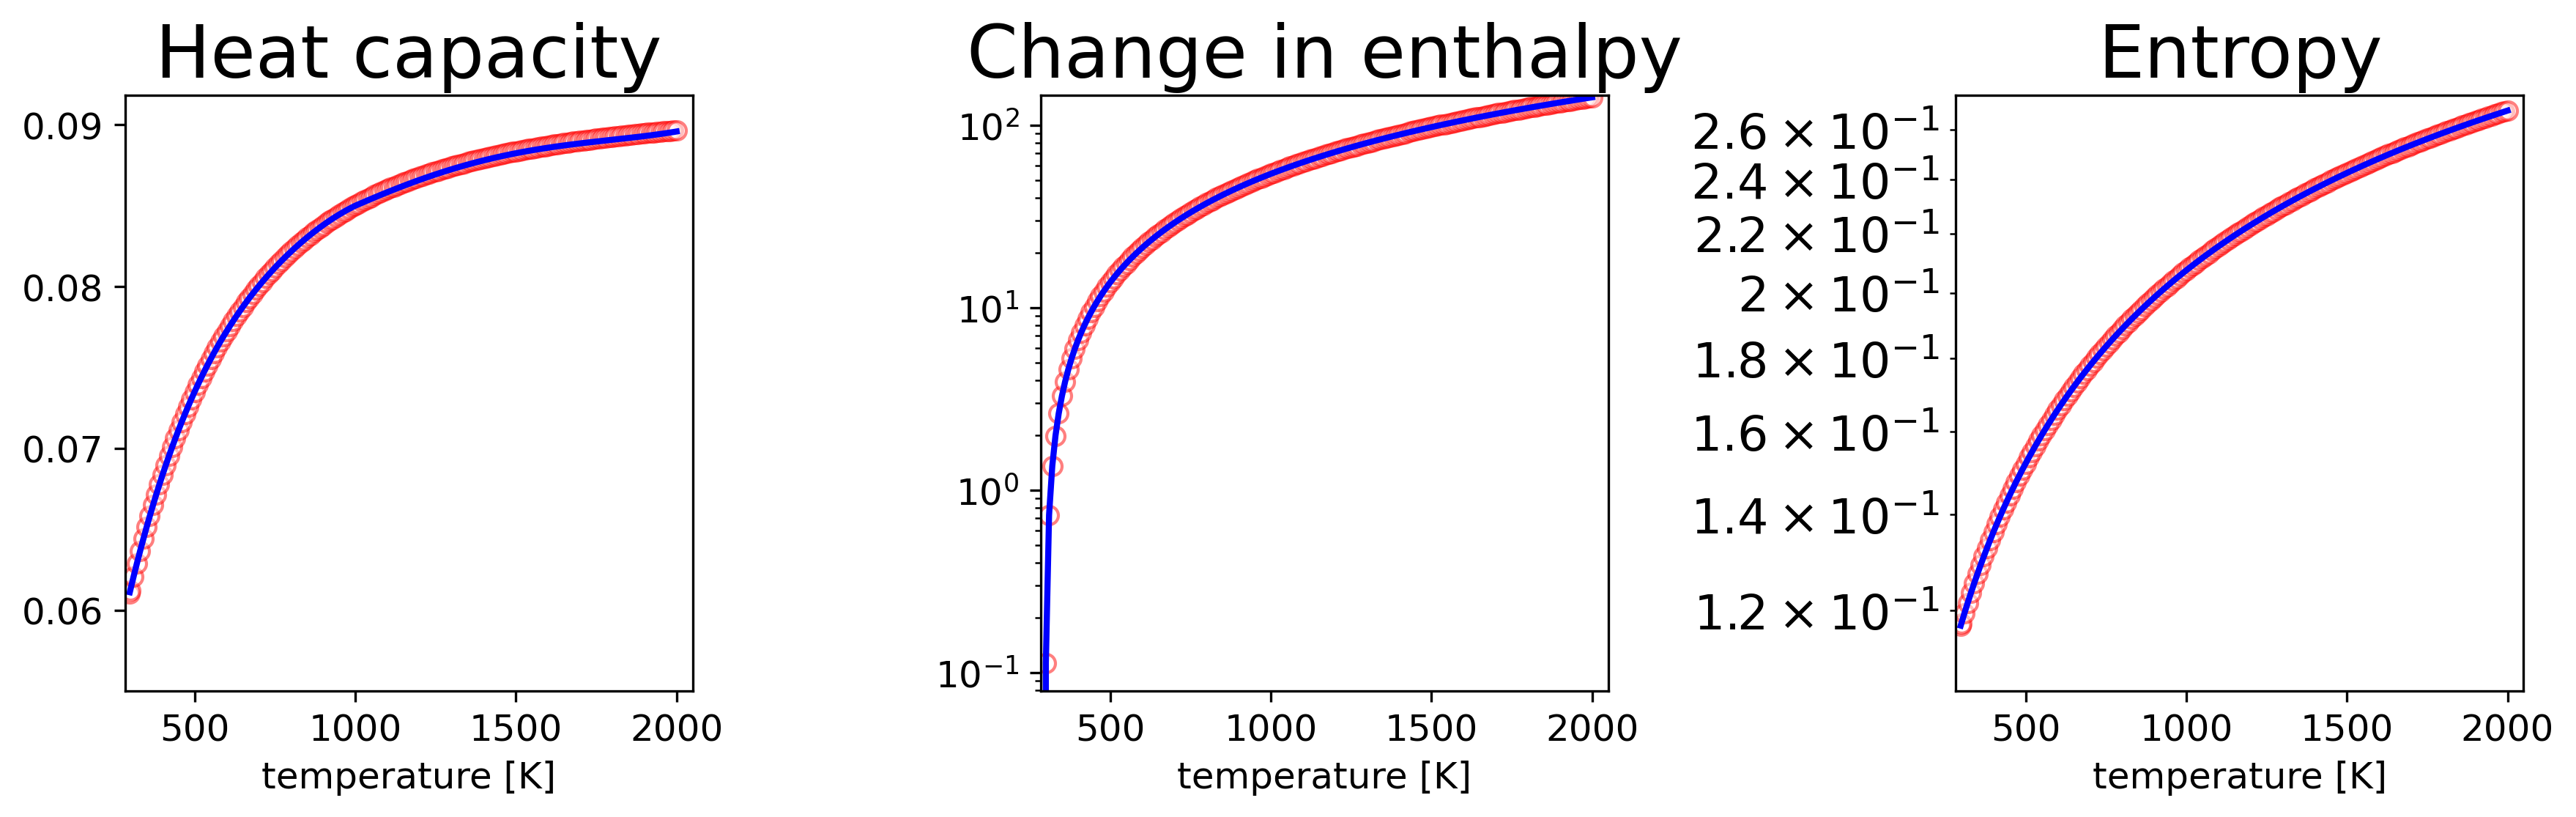

In [12]:
# create the array of temperatures in 10 degree increments
temperature = [298.15] #NOTE 298.15 must be first for the NASA polynomial routine to work!
T_low = 298.15
T_high = 2000.0
dT = 10.0 #temperature increment
temperature = np.append(temperature, np.arange(300.0, T_high+dT, dT))

list_of_species = 'sp_list.dat'
element = 'recalc_dft_sp'
info = open(list_of_species,'r')
species_list = info.readlines()
info.close()

new_output = open('dft_recalc.txt', 'w')

name_line = '\n'
species_line = '\n'

counter = -1
for species in species_list:
    counter += 1
    filename = species.strip()
    test = ig.Molecule()
    ig.parse_input_file(filename, test, element)
    ig.thermo(test, temperature)

    name_line += ' %s'%(test.name)
    if counter == 4:
        name_line +='\n'
        counter == -1
    species_line += test.species_lines

    ig.get_thermo_from_NASA(temperature, test)
    ig.compare_NASA_to_thermo(temperature, test)

name_line += '\n\n'
# new_output.write(name_line)
new_output.write(species_line)

new_output.close()

In [13]:
def update_long_desc(file_path):
    # Define the new longDesc content
    new_long_desc = (
        'Calculated by Torrie Asifor at Northeastern University using Statistical Mechanics. '
        'Based on DFT calculations by Colin Gallagher at Northeastern University'
    )

    # Read the original content from the file
    with open(file_path, 'r') as file:
        content = file.read()

    # Define a regex pattern to match the longDesc section
    pattern = re.compile(r'longDesc\s*=\s*u""".*?""",', re.DOTALL)

    # Replace the old longDesc with the new one
    updated_content = pattern.sub(f'longDesc = u"""{new_long_desc}""",', content)

    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(updated_content)

    print(f"Updated longDesc in {file_path}")

In [14]:
update_long_desc("dft_recalc.txt")

Updated longDesc in dft_recalc.txt


In [15]:
def convert_to_rmg_format(species_data, index):
    # Extract species name
    name_match = re.search(r'name = "(.+?)"', species_data)
    name = name_match.group(1) if name_match else "Unknown"
    print(name)

    # Extract thermo data
    thermo_str = re.findall(r'NASA\(\s*\[(\d+\.?\d*),\s*(\d+\.?\d*)\],\s*\[([^\]]+)\]\s*\),?', species_data)
    print(thermo_str)

    if len(thermo_str) != 2:
        raise ValueError("Thermo data does not contain two NASA polynomials")

    thermo_data = []
    for match in thermo_str:
        Tmin, Tmax, coeffs = match
        coeffs_list = [float(coeff) for coeff in coeffs.split(',')]
        thermo_data.append({
            "Tmin": Tmin,
            "Tmax": Tmax,
            "coeffs": coeffs_list
        })

    # Process thermo data to match the required format
    thermo_str = "thermo = NASA(\n    polynomials = [\n"
    for data in thermo_data:
        thermo_str += f"        NASAPolynomial(coeffs={data['coeffs']}, Tmin=({data['Tmin']}, 'K'), Tmax=({data['Tmax']}, 'K')),\n"
    thermo_str += f"    ],\n    Tmin=({thermo_data[0]['Tmin']}, 'K'),\n    Tmax=({thermo_data[1]['Tmax']}, 'K'),\n),"


    # Extract longDesc
    long_desc_match = re.search(r'longDesc = u"""(.+?)"""', species_data, re.DOTALL)
    long_desc = long_desc_match.group(1).strip() if long_desc_match else ""

    # Format for RMG
    rmg_format = f"""
entry(
    index = {index},
    label = "{name}",
    molecule =
\"\"\"
\"\"\",
    {thermo_str}
    shortDesc = u\"""{name}\""",
    longDesc =
u\"""{long_desc}
\""",
)
"""
    return rmg_format

In [16]:
def process_dft_recalc_file(input_file, output_file):
    with open(input_file, 'r') as infile:
        data = infile.read()

    # Split data into individual species
    species_list = re.split(r'\nspecies\(', data)
    # Remove the first empty element if it exists
    if not species_list[0].strip():
        species_list = species_list[1:]

    entries = []
    for idx, species_data in enumerate(species_list):
        if species_data.strip():  # Skip empty entries
            entry = convert_to_rmg_format(species_data, idx)
            entries.append(entry)

    with open(output_file, 'w') as outfile:
        for entry in entries:
            outfile.write(entry)
            outfile.write('\n')  # Add space between species entries

In [17]:
input_file = 'dft_recalc.txt'
output_file = 'CO2RR_Adsorbates_Cu111.py'
process_dft_recalc_file(input_file, output_file)

CH2OHX
[('298.0', '1000.0', '4.72735789E-01, 2.41008939E-02,\n \t\t -2.46801184E-05, 1.37773161E-08, -3.08137890E-12,\n \t\t -2.11574578E+04, 2.60923861E+00'), ('1000.0', '2000.0', '1.05681808E+01, -7.92065082E-03,\n \t\t 1.40261804E-05, -7.39838131E-09, 1.31411936E-12,\n \t\t -2.37294054E+04, -4.84995382E+01')]
CH2X
[('298.0', '1000.0', '4.66416892E-01, 2.26076886E-02,\n \t\t -3.69343557E-05, 3.09744704E-08, -9.99641342E-12,\n \t\t 8.00429404E+03, -3.72629114E+00'), ('1000.0', '2000.0', '7.09877494E+00, -4.33095407E-03,\n \t\t 7.66695886E-06, -4.02988705E-09, 7.12914077E-13,\n \t\t 6.58337634E+03, -3.59122248E+01')]
CH3X
[('298.0', '1000.0', '7.97287316E-01, 1.96521154E-02,\n \t\t -2.31595564E-05, 1.66221917E-08, -4.97799024E-12,\n \t\t -3.11100157E+03, -4.77956538E+00'), ('1000.0', '2000.0', '8.91016513E+00, -7.41666648E-03,\n \t\t 1.31686499E-05, -6.96776478E-09, 1.23966400E-12,\n \t\t -5.14493228E+03, -4.56077560E+01')]
CHOHX
[('298.0', '1000.0', '1.41019307E+00, 2.24007435E-02,\n 